In [32]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "python")))
import partition_function as pf
import ell_to_tau as et
import importlib
importlib.reload(pf)
importlib.reload(et)
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
import random

In [2]:
def even_partitions(L, min_val, num):
    """
    Generate even partitions of L/2 into three parts {2i, 2j, L/2-2i-2j}.
    Python translation of Mathematica evenPartitions[L, min, num].
    
    Returns random sample of size min(num, total_partitions).
    """
    partitions = []
    for i in range(min_val // 2, L // 4 + 1):
        for j in range(i, L // 4 - i + 1):
            if 2 * j <= L // 2 - 2 * i - 2 * j:
                l3 = L // 2 - 2 * i - 2 * j
                partitions.append((2 * i, 2 * j, l3))
                if i != j and j != L // 4 - i - j:
                    partitions.append((2 * j, 2 * i, l3))
    
    return random.sample(partitions, min(num, len(partitions)))

In [3]:
def analyze_partition(L, l1, l2, ref_terms=None, ref_logs=None):
    """
    Compute fermionic formulas and ghost*matter determinant for one partition.
    If ref_terms and ref_logs provided, normalize by reference partition.

    Args:
        L, l1, l2: Partition parameters
        ref_terms: tuple (term1_ref, ..., term6_ref) or None
        ref_logs: tuple (log_bdet_ref, log_prime_det_ref) or None

    Returns:
        (formula_added_bi, formula_no_added_bi, det_product) - normalized if references provided
    where:
        formula_added_bi = 1/|P1|² * |mean(bs²)|² * |η|² * mean(|bs|)^(52/12) * Im(τ)^(-13) * |η|^(-52)
        formula_no_added_bi = same but without mean(|bs|)^(52/12) term
        det_product = exp(log_bdet + log_prime_det) = det_B * det_A
    """
    # Get periods and tau
    P1, P2, P3 = et.periods_improved(L, l1, l2)
    tau = P2 / P1

    # Get eta
    eta_tau = et.dedekind_eta(tau)

    # Get bs from calculate_b (returns list of 6 complex values)
    bs = et.calculate_b(L, l1, l2)
    bs_arr = np.array(bs)

    # Compute formula components
    term1 = 1 / abs(P1)**2
    term2 = abs(np.mean(bs_arr**2))**2
    term3 = abs(eta_tau)**4
    term4 = np.mean(np.abs(bs_arr))**(52/12)
    term5 = tau.imag**(-13)
    term6 = abs(eta_tau)**(-52)

    # Normalize terms if reference provided
    if ref_terms is not None:
        term1 /= ref_terms[0]
        term2 /= ref_terms[1]
        term3 /= ref_terms[2]
        term4 /= ref_terms[3]
        term5 /= ref_terms[4]
        term6 /= ref_terms[5]

    # Compute both formula versions
    formula_added_bi = term1 * term2 * term3 * term4 * term5 * term6
    formula_no_added_bi = term1 * term2 * term3 * term5 * term6

    # Get determinants: (log_bdet, log_prime_det) where log_prime_det includes -13 factor
    log_bdet, log_prime_det = pf.combined_det2_log(L, l1, l2)

    # Normalize logs if reference provided (subtract in log space)
    if ref_logs is not None:
        log_bdet -= ref_logs[0]
        log_prime_det -= ref_logs[1]

    det_product = float(mp.e ** (log_bdet + log_prime_det))

    return formula_added_bi, formula_no_added_bi, det_product

In [5]:
def analyze_partitions(L=612, min_val=44, num=35, partition_list=None):
    """Analyze multiple partitions normalized by 5th-to-last reference.
    
    Args:
        L: Total length parameter
        min_val: Minimum value for partition generation (ignored if partition_list provided)
        num: Number of partitions to generate (ignored if partition_list provided)
        partition_list: Optional list of (l1, l2, l3) tuples. If provided, uses these instead of generating random ones.
    """
    if partition_list is None:
        partitions = even_partitions(L, min_val, num)
    else:
        partitions = partition_list

    # Get reference partition (5th to last)
    ref_partition = partitions[-5]
    ref_l1, ref_l2, ref_l3 = ref_partition

    # Compute reference values
    print(f"Computing reference partition: ({ref_l1}, {ref_l2}, {ref_l3})")

    # Get reference terms (call internal logic to extract individual terms)
    P1_ref, P2_ref, P3_ref = et.periods_improved(L, ref_l1, ref_l2)
    tau_ref = P2_ref / P1_ref
    eta_ref = et.dedekind_eta(tau_ref)
    bs_ref = et.calculate_b(L, ref_l1, ref_l2)
    bs_arr_ref = np.array(bs_ref)

    ref_terms = (
        1 / abs(P1_ref)**2,
        abs(np.mean(bs_arr_ref**2))**2,
        abs(eta_ref)**4,
        np.mean(np.abs(bs_arr_ref))**(52/12),
        tau_ref.imag**(-13),
        abs(eta_ref)**(-52)
    )

    log_bdet_ref, log_prime_det_ref = pf.combined_det2_log(L, ref_l1, ref_l2)
    ref_logs = (log_bdet_ref, log_prime_det_ref)

    print(f"Reference computed.\\n")

    # Now analyze all partitions with normalization
    results = []
    for l1, l2, l3 in partitions:
        try:
            formula_added, formula_no_added, det_prod = analyze_partition(L, l1, l2, ref_terms, ref_logs)
            results.append({
                'l1': l1, 'l2': l2, 'l3': l3,
                'formula_added_bi': formula_added,
                'formula_no_added_bi': formula_no_added,
                'det_product': det_prod
            })
            #print(f"✓ ({l1:3d}, {l2:3d}, {l3:3d}): added_bi={formula_added:.6e}, no_added_bi={formula_no_added:.6e}, det={det_prod:.6e}")
        except Exception as e:
            print(f"✗ ({l1}, {l2}, {l3}): {e}")

    return results

In [6]:
# Test with specific partitions from Mathematica (for comparison)
test_partitions = [
    (46, 66, 194), (124, 44, 138), (122, 52, 132), (114, 76, 116), 
    (48, 116, 142), (114, 74, 118), (104, 74, 128), (104, 84, 118), 
    (64, 82, 160), (50, 76, 180), (66, 108, 132), (54, 80, 172), 
    (114, 66, 126), (76, 98, 132), (110, 82, 114), (66, 74, 166), 
    (88, 58, 160), (44, 114, 148), (62, 108, 136), (92, 80, 134), 
    (72, 94, 140), (84, 106, 116), (94, 106, 106), (88, 84, 134), 
    (122, 60, 124), (76, 54, 176), (74, 92, 140), (80, 46, 180), 
    (100, 84, 122), (120, 44, 142), (78, 112, 116), (88, 46, 172), 
    (82, 74, 150), (116, 54, 136), (106, 74, 126)
]

# Analyze with specific test partitions
results_test = analyze_partitions(L=612, partition_list=test_partitions)

Computing reference partition: (78, 112, 116)


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:230: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *


Reference computed.\n


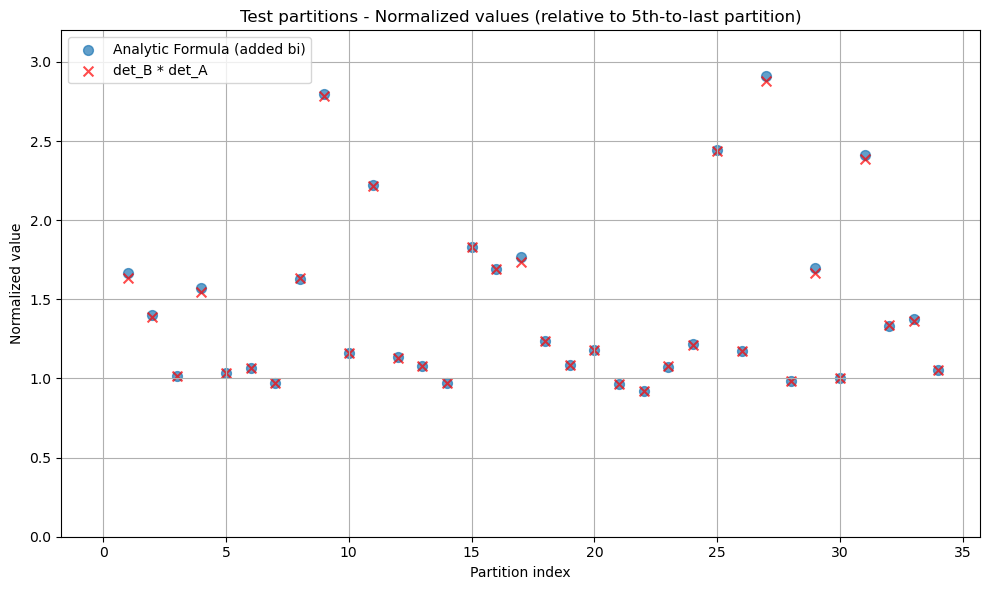

\nTest - Added bi: mean=1.530267e+00, std=7.331520e-01
Test - No added bi: mean=1.177706e+00, std=2.301950e-01
Test - Det products: mean=1.522723e+00, std=7.252553e-01


In [8]:
# Plot test results - all three quantities
formulas_added_bi = [r['formula_added_bi'] for r in results_test]
formulas_no_added_bi = [r['formula_no_added_bi'] for r in results_test]
det_prods_test = [r['det_product'] for r in results_test]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.scatter(range(len(formulas_added_bi)), formulas_added_bi, marker='o', s=50, label='Analytic Formula (added bi)', alpha=0.7)
#ax.scatter(range(len(formulas_no_added_bi)), formulas_no_added_bi, marker='s', s=50, label='Formula (no added bi)', alpha=0.7, color='green')
ax.scatter(range(len(det_prods_test)), det_prods_test, marker='x', s=50, color='red', label='det_B * det_A', alpha=0.7)

ax.set_xlabel('Partition index')
ax.set_ylabel('Normalized value')
ax.set_title('Test partitions - Normalized values (relative to 5th-to-last partition)')
ax.legend()
ax.set_ylim([0,3.2])
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"\\nTest - Added bi: mean={np.mean(formulas_added_bi):.6e}, std={np.std(formulas_added_bi):.6e}")
print(f"Test - No added bi: mean={np.mean(formulas_no_added_bi):.6e}, std={np.std(formulas_no_added_bi):.6e}")
print(f"Test - Det products: mean={np.mean(det_prods_test):.6e}, std={np.std(det_prods_test):.6e}")

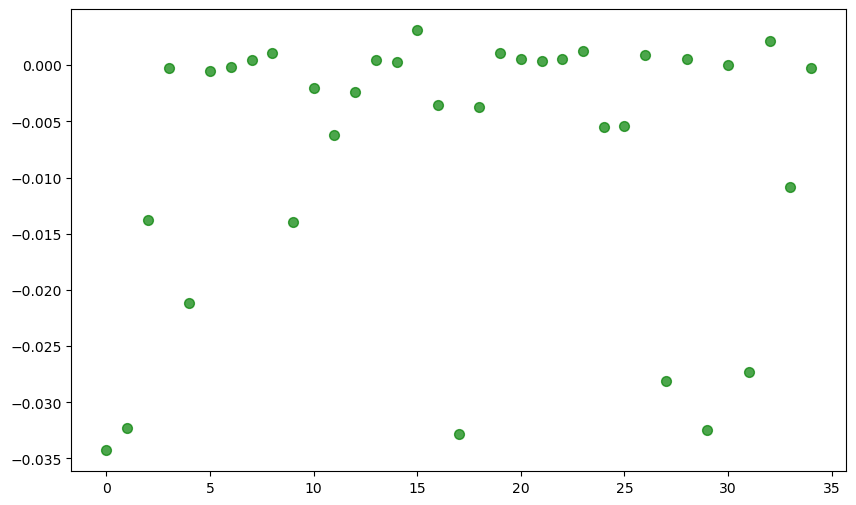

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.scatter(range(len(formulas_no_added_bi)), np.array(det_prods_test)-np.array(formulas_added_bi), s=50, label='Subtraction', alpha=0.7, color='green')

In [21]:
# Scaling analysis - multiply all (L, l1, l2, l3) by integer factors 1-5
scales = range(1, 6)
scaling_results = []

print("Running scaling analysis...")
for scale in scales:
    scaled_L = 612 * scale
    scaled_partitions = [(l1*scale, l2*scale, l3*scale) for l1, l2, l3 in test_partitions]
    print(f"\nScale {scale}: L={scaled_L}")
    results_scaled = analyze_partitions(L=scaled_L, partition_list=scaled_partitions)
    scaling_results.append(results_scaled)

Running scaling analysis...

Scale 1: L=612
Computing reference partition: (78, 112, 116)


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:230: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *


Reference computed.\n

Scale 2: L=1224
Computing reference partition: (156, 224, 232)
Reference computed.\n

Scale 3: L=1836
Computing reference partition: (234, 336, 348)
Reference computed.\n

Scale 4: L=2448
Computing reference partition: (312, 448, 464)
Reference computed.\n

Scale 5: L=3060
Computing reference partition: (390, 560, 580)
Reference computed.\n


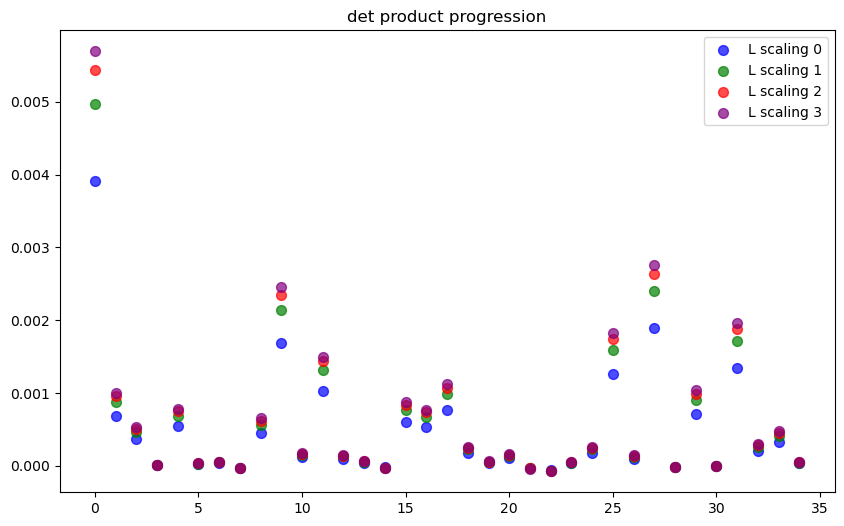

In [39]:

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_title("det product progression")
colors = ["blue","green","red","purple","orange"]
i = scaling_results[0]
formulas_added_bi_0 = []
det_product_0 = []
for j in i:
    formulas_added_bi_0.append(j['formula_added_bi'])
    det_product_0.append(j["det_product"])
for num,i in enumerate(scaling_results[1:]):
    formulas_added_bi = []
    det_product = []
    for j in i:
        formulas_added_bi.append(j['formula_added_bi'])
        det_product.append(j["det_product"])
    ax.scatter(range(len(formulas_no_added_bi)), np.array(det_product)-np.array(det_product_0), s=50, label='L scaling {}'.format(num), alpha=0.7, color=colors[num])
ax.legend()

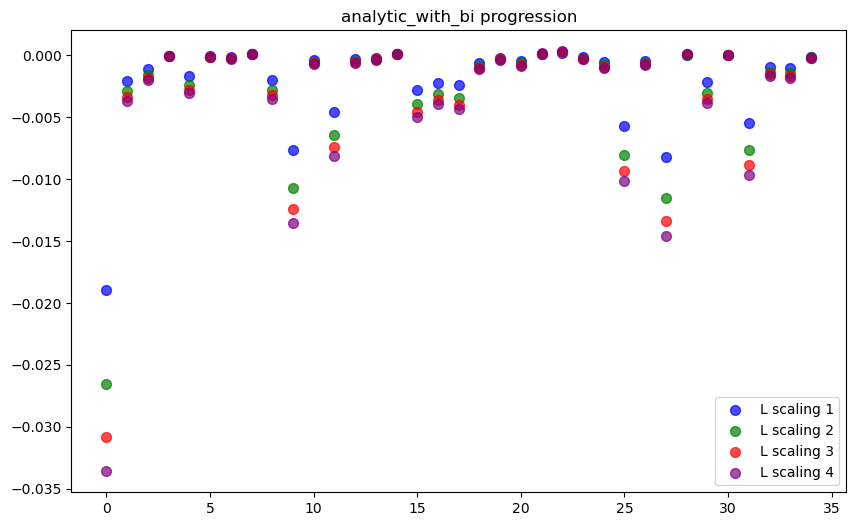

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_title("analytic_with_bi progression")
colors = ["blue","green","red","purple","orange"]
i = scaling_results[0]
formulas_added_bi_0 = []
det_product_0 = []
for j in i:
    formulas_added_bi_0.append(j['formula_added_bi'])
    det_product_0.append(j["det_product"])
for num,i in enumerate(scaling_results[1:]):
    formulas_added_bi = []
    det_product = []
    for j in i:
        formulas_added_bi.append(j['formula_added_bi'])
        det_product.append(j["det_product"])
    ax.scatter(range(len(formulas_no_added_bi)), np.array(formulas_added_bi)-np.array(formulas_added_bi_0), s=50, label='L scaling {}'.format(num+1), alpha=0.7, color=colors[num])

ax.legend()

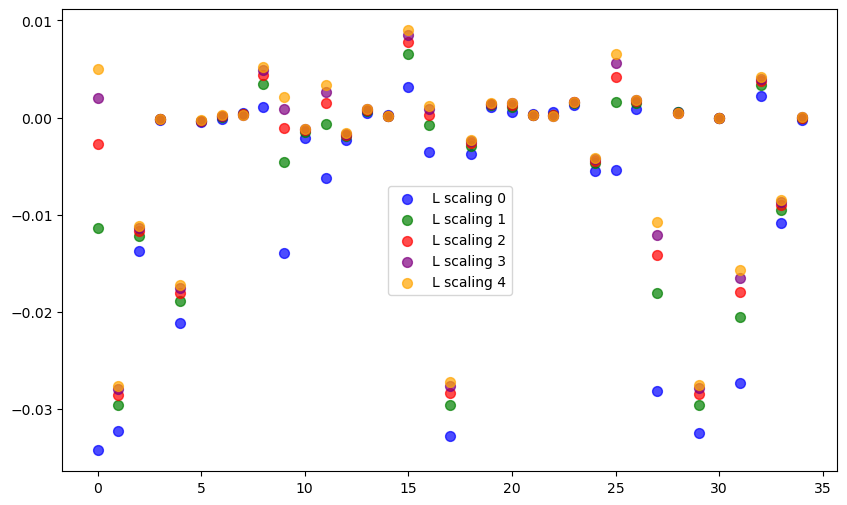

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors = ["blue","green","red","purple","orange"]
for num,i in enumerate(scaling_results):
    formulas_added_bi = []
    det_product = []
    for j in i:
        formulas_added_bi.append(j['formula_added_bi'])
        det_product.append(j["det_product"])
    ax.scatter(range(len(formulas_no_added_bi)), np.array(det_product)-np.array(formulas_added_bi), s=50, label='L scaling {}'.format(num), alpha=0.7, color=colors[num])
ax.legend()

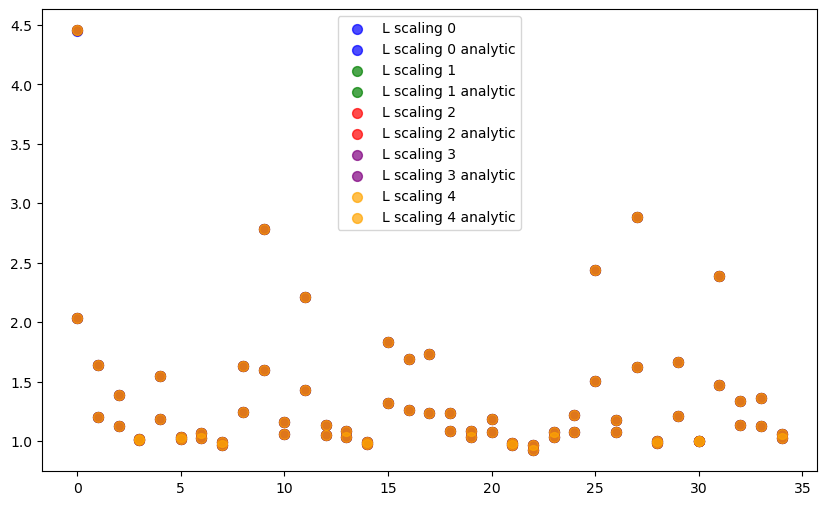

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors = ["blue","green","red","purple","orange"]
for num,i in enumerate(scaling_results):
    formulas_added_bi = []
    det_product = []
    for j in i:
        formulas_added_bi.append(j['formula_added_bi'])
        det_product.append(j["det_product"])
    ax.scatter(range(len(formulas_no_added_bi)), np.array(det_product), s=50, label='L scaling {}'.format(num), alpha=0.7, color=colors[num])
    ax.scatter(range(len(formulas_no_added_bi)), np.array(formulas_no_added_bi), s=50, label='L scaling {} analytic'.format(num), alpha=0.7, color=colors[num])
ax.legend()

In [9]:
# Generate and analyze partitions
results = analyze_partitions(L=612, min_val=44, num=35)

Computing reference partition: (106, 82, 118)
Reference computed.\n
✓ ( 82,  44, 180): formula=2.894228e+00, det=3.007241e+00
✓ ( 48,  50, 208): formula=7.353367e+00, det=8.175361e+00
✓ ( 56, 116, 134): formula=1.214324e+00, det=1.341533e+00
✓ ( 54, 108, 144): formula=1.322762e+00, det=1.466594e+00
✓ ( 94, 104, 108): formula=9.187808e-01, det=9.421667e-01
✓ ( 62,  82, 162): formula=1.593421e+00, det=1.746865e+00
✓ ( 90,  58, 158): formula=1.616783e+00, det=1.669568e+00
✓ ( 58, 110, 138): formula=1.211967e+00, det=1.334934e+00
✓ ( 72, 116, 118): formula=1.001987e+00, det=1.075042e+00
✓ ( 66,  76, 164): formula=1.646793e+00, det=1.792279e+00
✓ ( 44,  60, 202): formula=5.605470e+00, det=6.292939e+00
✓ ( 90,  94, 122): formula=9.604664e-01, det=9.935512e-01
✓ ( 50,  74, 182): formula=2.688290e+00, det=3.005535e+00
✓ (114,  66, 126): formula=1.177086e+00, det=1.155737e+00
✓ ( 84, 108, 114): formula=9.382108e-01, det=9.824015e-01
✓ ( 50,  88, 168): formula=1.921260e+00, det=2.146399e+00
✓ ( 

In [ ]:
# Plot random results - all three quantities
formulas_added_bi = [r['formula_added_bi'] for r in results]
formulas_no_added_bi = [r['formula_no_added_bi'] for r in results]
det_prods = [r['det_product'] for r in results]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.scatter(range(len(formulas_added_bi)), formulas_added_bi, marker='o', s=50, label='Formula (added bi)', alpha=0.7)
ax.scatter(range(len(formulas_no_added_bi)), formulas_no_added_bi, marker='s', s=50, label='Formula (no added bi)', alpha=0.7, color='green')
ax.scatter(range(len(det_prods)), det_prods, marker='x', s=50, color='red', label='det_B * det_A', alpha=0.7)

ax.set_xlabel('Partition index')
ax.set_ylabel('Normalized value')
ax.set_title('Random partitions - Normalized values (relative to 5th-to-last partition)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"\\nRandom - Added bi: mean={np.mean(formulas_added_bi):.6e}, std={np.std(formulas_added_bi):.6e}")
print(f"\\nRandom - No added bi: mean={np.mean(formulas_no_added_bi):.6e}, std={np.std(formulas_no_added_bi):.6e}")
print(f"Random - Det products: mean={np.mean(det_prods):.6e}, std={np.std(det_prods):.6e}")

In [53]:
print(et.calculate_b(2*(186+101+23),186,101))
print(et.calculate_b(2*(186+101+23),23,186))

[np.complex128(0.5910015024216081+0.38297563225449566j), np.complex128(0.6751847070075329-0.17667290535667568j), np.complex128(0.6873474234337831-0.16005772308736324j), np.complex128(0.5910015024216081+0.38297563225449566j), np.complex128(0.6751847070075329-0.17667290535667568j), np.complex128(0.6873474234337831-0.16005772308736324j)]
[np.complex128(0.6873474234337704-0.1600577230873525j), np.complex128(0.5910015024216084+0.38297563225449377j), np.complex128(0.6751847070075491-0.17667290535667504j), np.complex128(0.6873474234337704-0.1600577230873525j), np.complex128(0.5910015024216084+0.38297563225449377j), np.complex128(0.6751847070075491-0.17667290535667504j)]


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:230: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *


In [55]:
122+52+132

306

In [ ]:
# divide by (78, 112, 116)
# test against (122, 52, 132)
L = 2*(78+112+116)
l1 = 78
l2 = 112
P1, P2, P3 = et.periods_improved(L, l1, l2)
tau = P2 / P1

# Get eta
eta_tau = et.dedekind_eta(tau)

# Get bs from calculate_b (returns list of 6 complex values)
bs = et.calculate_b(L, l1, l2)
bs_arr = np.array(bs)

# Compute formula components
term1 = 1 / abs(P1)**2
term2 = abs(np.mean(bs_arr**2))**2
term3 = abs(eta_tau)**4
term4 = np.mean(np.abs(bs_arr))**(52/12)
term5 = tau.imag**(-13)
term6 = abs(eta_tau)**(-52)
term7 = tau

l1 = 122
l2 = 52
P1, P2, P3 = et.periods_improved(L, l1, l2)
tau = P2 / P1

# Get eta
eta_tau = et.dedekind_eta(tau)

# Get bs from calculate_b (returns list of 6 complex values)
bs = et.calculate_b(L, l1, l2)
bs_arr = np.array(bs)

# Compute formula components
term12 = 1 / abs(P1)**2
term22 = abs(np.mean(bs_arr**2))**2
term32 = abs(eta_tau)**4
term42 = np.mean(np.abs(bs_arr))**(52/12)
term52 = tau.imag**(-13)
term62 = abs(eta_tau)**(-52)
term72 = tau

In [69]:
print(1/(term1*term2*term3*term4*term5*term6/(term12*term22*term32*term42*term52*term62)))

1.4012359634873899


Computing L-scan for data1 partitions...
k= 1: L_formula= 26, L_det= 52, formula=3.950136e+00, det=3.510669e+00
k= 3: L_formula= 78, L_det=104, formula=3.704984e+00, det=3.575712e+00
k= 5: L_formula=130, L_det=156, formula=3.650524e+00, det=3.593451e+00
k= 7: L_formula=182, L_det=208, formula=3.624500e+00, det=3.601269e+00
k= 9: L_formula=234, L_det=260, formula=3.608845e+00, det=3.605546e+00
k=11: L_formula=286, L_det=312, formula=3.598241e+00, det=3.608198e+00
k=13: L_formula=338, L_det=364, formula=3.590511e+00, det=3.609982e+00
k=15: L_formula=390, L_det=416, formula=3.584587e+00, det=3.611253e+00
k=17: L_formula=442, L_det=468, formula=3.579881e+00, det=3.612199e+00
k=19: L_formula=494, L_det=520, formula=3.576036e+00, det=3.612926e+00
k=21: L_formula=546, L_det=572, formula=3.572827e+00, det=3.613501e+00
k=23: L_formula=598, L_det=624, formula=3.570102e+00, det=3.613964e+00
k=25: L_formula=650, L_det=676, formula=3.567753e+00, det=3.614346e+00
k=27: L_formula=702, L_det=728, form

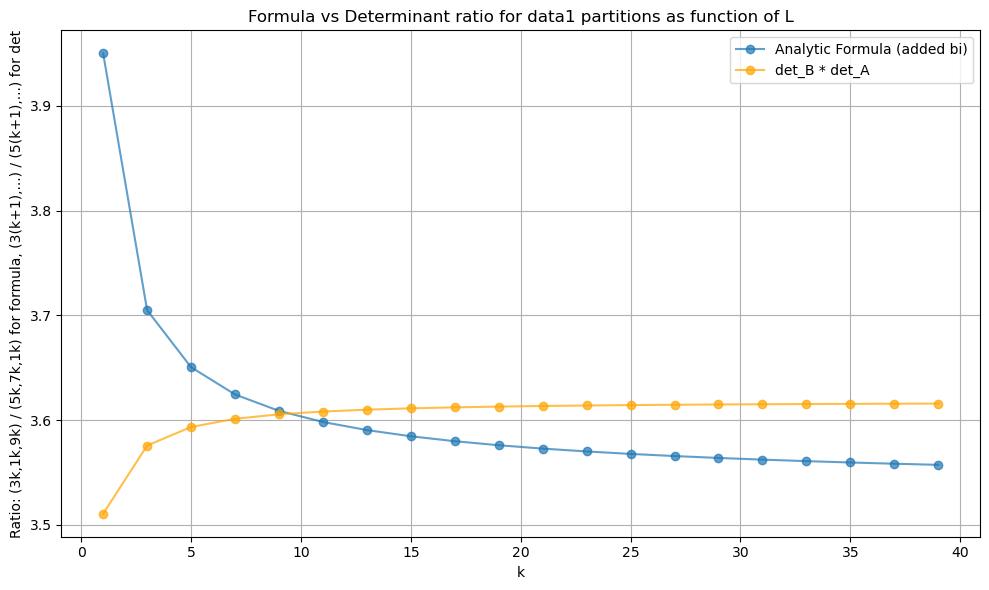


L-scan results for data1 partition ratios:
Formula (added bi): mean=3.605346e+00, std=8.685674e-02
Det products: mean=3.604509e+00, std=2.352921e-02


In [4]:
# L-scan for data1 partitions: numerator (3k,1k,9k) / denominator (5k,7k,1k)
# Formula terms use k scaling, determinants use (k+1) scaling (matching data1)
kvals = range(1, 41,2)  # k from 1 to 20
formulas_added_bi_Lscan = []
det_prods_Lscan = []

print("Computing L-scan for data1 partitions...")
for k in kvals:
    kp1 = k + 1
    
    # ===== FORMULA TERMS: use k scaling =====
    L_formula = 26 * k
    
    # Denominator partition for formula (reference)
    l1_den_formula = 5 * k
    l2_den_formula = 7 * k
    
    # Compute reference formula terms (denominator, k scaling)
    P1_ref, P2_ref, P3_ref = et.periods_improved(L_formula, l1_den_formula, l2_den_formula)
    tau_ref = P2_ref / P1_ref
    eta_ref = et.dedekind_eta(tau_ref)
    bs_ref = et.calculate_b(L_formula, l1_den_formula, l2_den_formula)
    bs_arr_ref = np.array(bs_ref)
    
    ref_terms = (
        1 / abs(P1_ref)**2,
        abs(np.mean(bs_arr_ref**2))**2,
        abs(eta_ref)**4,
        np.mean(np.abs(bs_arr_ref))**(52/12),
        tau_ref.imag**(-13),
        abs(eta_ref)**(-52)
    )
    
    # Numerator partition for formula (k scaling)
    l1_num_formula = 3 * k
    l2_num_formula = 1 * k
    
    # Compute numerator formula terms (k scaling)
    P1_num, P2_num, P3_num = et.periods_improved(L_formula, l1_num_formula, l2_num_formula)
    tau_num = P2_num / P1_num
    eta_num = et.dedekind_eta(tau_num)
    bs_num = et.calculate_b(L_formula, l1_num_formula, l2_num_formula)
    bs_arr_num = np.array(bs_num)
    
    num_terms = (
        1 / abs(P1_num)**2,
        abs(np.mean(bs_arr_num**2))**2,
        abs(eta_num)**4,
        np.mean(np.abs(bs_arr_num))**(52/12),
        tau_num.imag**(-13),
        abs(eta_num)**(-52)
    )
    
    # Compute formula ratio (term-by-term division)
    formula_ratio_terms = tuple(num_terms[i] / ref_terms[i] for i in range(6))
    formula_added_bi = np.prod(formula_ratio_terms)  # All 6 terms
    
    # ===== DETERMINANTS: use (k+1) scaling =====
    L_det = 26 * kp1
    
    # Denominator partition for determinants (k+1 scaling)
    l1_den_det = 5 * kp1
    l2_den_det = 7 * kp1
    log_bdet_ref, log_prime_det_ref = pf.combined_det2_log(L_det, l1_den_det, l2_den_det)
    
    # Numerator partition for determinants (k+1 scaling)
    l1_num_det = 3 * kp1
    l2_num_det = 1 * kp1
    log_bdet_num, log_prime_det_num = pf.combined_det2_log(L_det, l1_num_det, l2_num_det)
    
    # Compute determinant ratio (subtract in log space, then exponentiate)
    log_det_ratio = (log_bdet_num - log_bdet_ref) + (log_prime_det_num - log_prime_det_ref)
    det_product = float(mp.e ** log_det_ratio)
    
    formulas_added_bi_Lscan.append(formula_added_bi)
    det_prods_Lscan.append(det_product)
    
    print(f"k={k:2d}: L_formula={L_formula:3d}, L_det={L_det:3d}, formula={formula_added_bi:.6e}, det={det_product:.6e}")

print("\nL-scan complete.")

# Plot both quantities vs k (or L)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(kvals, formulas_added_bi_Lscan, marker='o', linestyle='-',
        label='Analytic Formula (added bi)', alpha=0.7)
ax.plot(kvals, det_prods_Lscan, marker='o', linestyle='-', color='orange',
        label='det_B * det_A', alpha=0.7)

ax.set_xlabel('k')
ax.set_ylabel('Ratio: (3k,1k,9k) / (5k,7k,1k) for formula, (3(k+1),...) / (5(k+1),...) for det')
ax.set_title('Formula vs Determinant ratio for data1 partitions as function of L')
ax.legend()
ax.grid(True)
#ax.set_ylim([3.4, 3.9])  # Match the user's example plot range

plt.tight_layout()
plt.show()

print(f"\nL-scan results for data1 partition ratios:")
print(f"Formula (added bi): mean={np.mean(formulas_added_bi_Lscan):.6e}, std={np.std(formulas_added_bi_Lscan):.6e}")
print(f"Det products: mean={np.mean(det_prods_Lscan):.6e}, std={np.std(det_prods_Lscan):.6e}")

Computing L-scan for data1 partitions...
k= 1: L_formula= 24, L_det= 52, formula=3.225374e+00, det=2.413562e+00
k= 3: L_formula= 72, L_det=104, formula=3.225374e+00, det=2.454240e+00
k= 5: L_formula=120, L_det=156, formula=3.225374e+00, det=2.465589e+00
k= 7: L_formula=168, L_det=208, formula=3.225374e+00, det=2.470648e+00
k= 9: L_formula=216, L_det=260, formula=3.225374e+00, det=2.473437e+00
k=11: L_formula=264, L_det=312, formula=3.225374e+00, det=2.475174e+00
k=13: L_formula=312, L_det=364, formula=3.225374e+00, det=2.476347e+00
k=15: L_formula=360, L_det=416, formula=3.225374e+00, det=2.477185e+00
k=17: L_formula=408, L_det=468, formula=3.225374e+00, det=2.477811e+00
k=19: L_formula=456, L_det=520, formula=3.225374e+00, det=2.478293e+00
k=21: L_formula=504, L_det=572, formula=3.225374e+00, det=2.478674e+00
k=23: L_formula=552, L_det=624, formula=3.225374e+00, det=2.478982e+00
k=25: L_formula=600, L_det=676, formula=3.225374e+00, det=2.479235e+00
k=27: L_formula=648, L_det=728, form

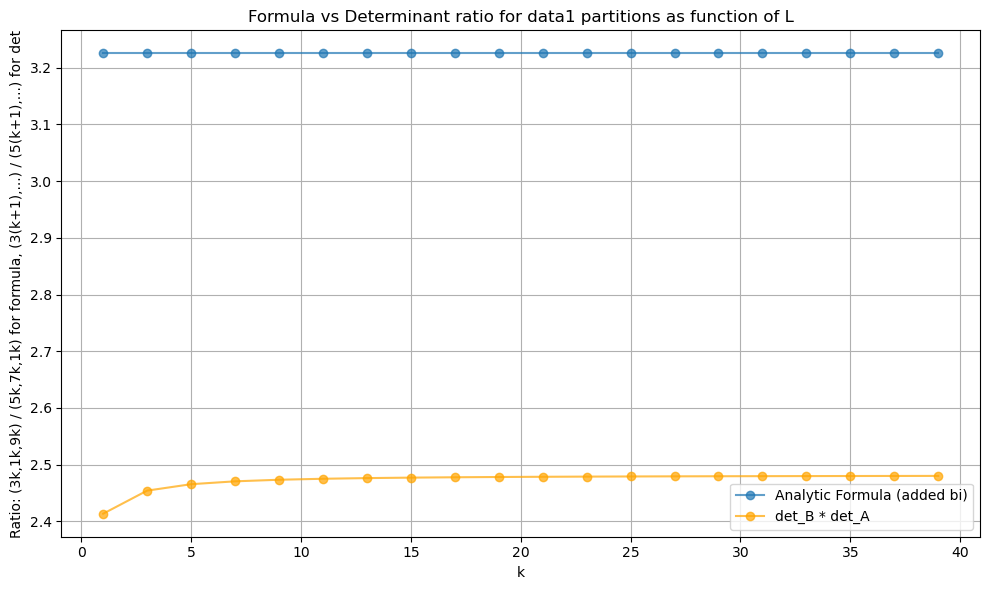


L-scan results for data1 partition ratios:
Formula (added bi): mean=3.225374e+00, std=5.348171e-13
Det products: mean=2.472916e+00, std=1.494707e-02


In [100]:
# Formula terms use k scaling, determinants use (k+1) scaling (matching data1)
kvals = range(1, 41,2)  # k from 1 to 20
formulas_added_bi_Lscan = []
det_prods_Lscan = []

print("Computing L-scan for data1 partitions...")
for k in kvals:
    kp1 = k + 1
    
    # ===== FORMULA TERMS: use k scaling =====
    L_formula = 24 * k
    
    # Denominator partition for formula (reference)
    l1_den_formula = 5 * k
    l2_den_formula = 7 * k
    
    # Compute reference formula terms (denominator, k scaling)
    P1_ref, P2_ref, P3_ref = et.periods_improved(L_formula, l1_den_formula, l2_den_formula)
    tau_ref = P2_ref / P1_ref
    eta_ref = et.dedekind_eta(tau_ref)
    bs_ref = et.calculate_b(L_formula, l1_den_formula, l2_den_formula)
    bs_arr_ref = np.array(bs_ref)
    
    ref_terms = (
        tau_ref.imag**(-13),
        abs(eta_ref)**(-52)
    )
    
    # Numerator partition for formula (k scaling)
    l1_num_formula = 9 * k
    l2_num_formula = 3 * k
    
    # Compute numerator formula terms (k scaling)
    P1_num, P2_num, P3_num = et.periods_improved(L_formula, l1_num_formula, l2_num_formula)
    tau_num = P2_num / P1_num
    eta_num = et.dedekind_eta(tau_num)
    bs_num = et.calculate_b(L_formula, l1_num_formula, l2_num_formula)
    bs_arr_num = np.array(bs_num)
    
    num_terms = (
        
        tau_num.imag**(-13),
        abs(eta_num)**(-52)
    )
    
    # Compute formula ratio (term-by-term division)
    formula_ratio_terms = tuple(num_terms[i] / ref_terms[i] for i in range(2))
    formula_added_bi = np.prod(formula_ratio_terms)  # All 6 terms
    
    # ===== DETERMINANTS: use (k+1) scaling =====
    L_det = 26 * kp1
    
    # Denominator partition for determinants (k+1 scaling)
    l1_den_det = 5 * kp1
    l2_den_det = 7 * kp1
    log_bdet_ref, log_prime_det_ref = pf.combined_det2_log(L_det, l1_den_det, l2_den_det)
    
    # Numerator partition for determinants (k+1 scaling)
    l1_num_det = 9 * kp1
    l2_num_det = 3 * kp1
    log_bdet_num, log_prime_det_num = pf.combined_det2_log(L_det, l1_num_det, l2_num_det)
    
    # Compute determinant ratio (subtract in log space, then exponentiate)
    log_det_ratio =  (log_prime_det_num - log_prime_det_ref)
    det_product = float(mp.e ** log_det_ratio)*np.mean(np.abs(bs_arr_num))**(-26/12)/np.mean(np.abs(bs_arr_ref))**(-26/12)
    
    formulas_added_bi_Lscan.append(formula_added_bi)
    det_prods_Lscan.append(det_product)
    
    print(f"k={k:2d}: L_formula={L_formula:3d}, L_det={L_det:3d}, formula={formula_added_bi:.6e}, det={det_product:.6e}")

print("\nL-scan complete.")

# Plot both quantities vs k (or L)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(kvals, formulas_added_bi_Lscan, marker='o', linestyle='-',
        label='Analytic Formula (added bi)', alpha=0.7)
ax.plot(kvals, det_prods_Lscan, marker='o', linestyle='-', color='orange',
        label='det_B * det_A', alpha=0.7)

ax.set_xlabel('k')
ax.set_ylabel('Ratio: (3k,1k,9k) / (5k,7k,1k) for formula, (3(k+1),...) / (5(k+1),...) for det')
ax.set_title('Formula vs Determinant ratio for data1 partitions as function of L')
ax.legend()
ax.grid(True)
#ax.set_ylim([3.4, 3.9])  # Match the user's example plot range

plt.tight_layout()
plt.show()

print(f"\nL-scan results for data1 partition ratios:")
print(f"Formula (added bi): mean={np.mean(formulas_added_bi_Lscan):.6e}, std={np.std(formulas_added_bi_Lscan):.6e}")
print(f"Det products: mean={np.mean(det_prods_Lscan):.6e}, std={np.std(det_prods_Lscan):.6e}")

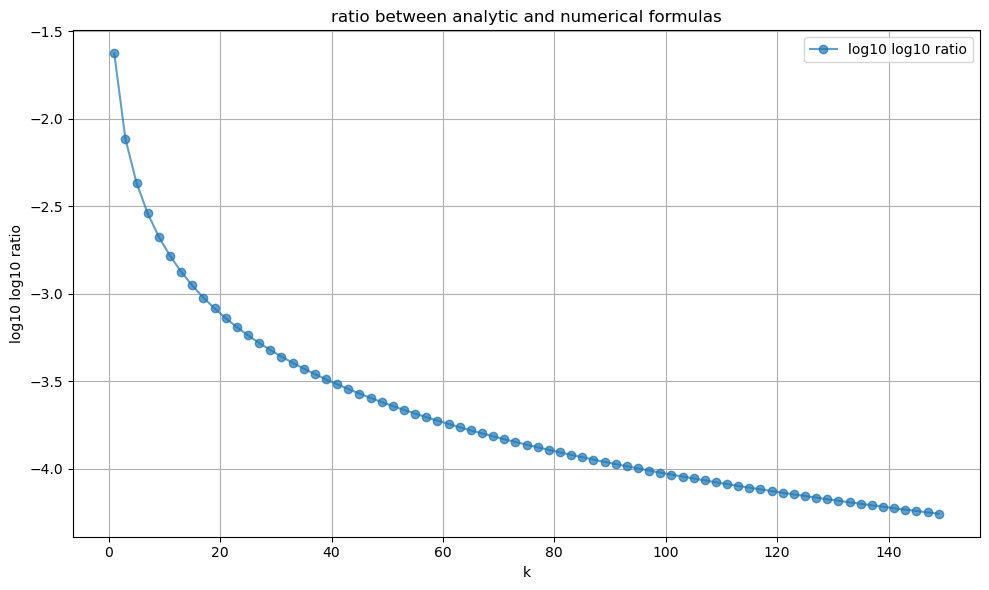


L-scan results for data1 partition ratios:
Formula (added bi): mean=2.359825e+00, std=6.792762e-03


In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(kvals, np.log10(np.log10(np.array(formulas_added_bi_Lscan)/np.array(det_prods_Lscan))), marker='o', linestyle='-',
        label='log10 log10 ratio', alpha=0.7)
#plt.plot(kvals,-np.log10(kvals), label="log10 k")
#ax.plot(kvals, det_prods_Lscan, marker='o', linestyle='-', color='orange',
#        label='det_B * det_A', alpha=0.7)

ax.set_xlabel('k')
ax.set_ylabel('log10 log10 ratio')
ax.set_title('ratio between analytic and numerical formulas')
ax.legend()
ax.grid(True)
#ax.set_ylim([3.4, 3.9])  # Match the user's example plot range

plt.tight_layout()
plt.show()

print(f"\nL-scan results for data1 partition ratios:")
print(f"Formula (added bi): mean={np.mean(formulas_added_bi_Lscan):.6e}, std={np.std(formulas_added_bi_Lscan):.6e}")
#print(f"Det products: mean={np.mean(det_prods_Lscan):.6e}, std={np.std(det_prods_Lscan):.6e}")

In [50]:
def test_formula(l1_scaling_num, l2_scaling_num, l1_scaling_den, l2_scaling_den,L,
                             kvals_range, bi_exponent=9/2, plot=True):
    """

    
    Args:
        l1_scaling_num, l2_scaling_num: multipliers for numerator partition (e.g. 3, 9)
        l1_scaling_den, l2_scaling_den: multipliers for denominator partition (e.g. 5, 7)
        kvals_range: range of k values (e.g. range(1, 101, 2))
        bi_exponent: exponent for mean(|bs|) term (default 9/2)
        plot: whether to generate plots (default True)
    
    Returns:
        dict with keys 'kvals', 'formula', 'formula2', 'det', for further analysis
    """
    kvals = list(kvals_range)
    formulas = []
    formulas2 = []
    dets = []
    
    L_formula_mult = L
    l3_scaling_num = L // 2 - l1_scaling_num - l2_scaling_num
    l3_scaling_den = L // 2 - l1_scaling_den - l2_scaling_den
    
    print(f"formula test num=({l1_scaling_num}k, {l2_scaling_num}k), "
          f"den=({l1_scaling_den}k, {l2_scaling_den}k)")
    print(f"L_formula = {L_formula_mult}*k, L_det = {L}*(k+1), "
          f"bi_exponent = {bi_exponent}")
    print(f"l3_den_formula = {l3_scaling_den}*k, "
          f"l3_num_formula = {l3_scaling_num}*k")
    print()
    
    for k in kvals:
        kp1 = k + 1
        
        # ===== FORMULA TERMS: use k scaling =====
        L_formula = L_formula_mult * k
        
        # Denominator partition (reference)
        l1_den_f = l1_scaling_den * k
        l2_den_f = l2_scaling_den * k
        l3_den_f = l3_scaling_den * k
        
        P1_ref, P2_ref, P3_ref = et.periods_improved(L_formula, l1_den_f, l2_den_f)
        tau_ref = P2_ref / P1_ref
        eta_ref = et.dedekind_eta(tau_ref)
        bs_ref = et.calculate_b(L_formula, l1_den_f, l2_den_f)
        bs_arr_ref = np.array(et.average_b(L_formula, l1_den_f, l2_den_f, bs_ref))
        theta_ref = [2 * np.pi * li / L_formula for li in [l1_den_f, l2_den_f, l3_den_f]]
        trig_ref = 2 + 2 * sum(np.cos(2 * np.pi / 3 - 2 * th) for th in theta_ref)
        
        ref_terms = (
            1 / abs(P1_ref)**2,
            abs(np.mean(bs_arr_ref**2))**2,
            np.mean(np.abs(bs_arr_ref))**bi_exponent,
            tau_ref.imag**(-13),
            abs(eta_ref)**(-48)
        )
        
        ref_terms2 = (
            np.mean(np.abs(bs_arr_ref))**8.5,
            1 / abs(P1_ref)**2,
            abs(eta_ref)**(-48),
            tau_ref.imag**(-13),
            trig_ref
        )
        
        # Numerator partition
        l1_num_f = l1_scaling_num * k
        l2_num_f = l2_scaling_num * k
        l3_num_f = l3_scaling_num * k
        
        P1_num, P2_num, P3_num = et.periods_improved(L_formula, l1_num_f, l2_num_f)
        tau_num = P2_num / P1_num
        eta_num = et.dedekind_eta(tau_num)
        bs_num = et.calculate_b(L_formula, l1_num_f, l2_num_f)
        bs_arr_num = np.array(et.average_b(L_formula, l1_num_f, l2_num_f, bs_num))
        theta_num = [2 * np.pi * li / L_formula for li in [l1_num_f, l2_num_f, l3_num_f]]
        trig_num = 2 + 2 * sum(np.cos(2 * np.pi / 3 - 2 * th) for th in theta_num)
        
        num_terms = (
            1 / abs(P1_num)**2,
            abs(np.mean(bs_arr_num**2))**2,
            np.mean(np.abs(bs_arr_num))**bi_exponent,
            tau_num.imag**(-13),
            abs(eta_num)**(-48)
        )
        
        num_terms2 = (
            np.mean(np.abs(bs_arr_num))**8.5,
            1 / abs(P1_num)**2,
            abs(eta_num)**(-48),
            tau_num.imag**(-13),
            trig_num
        )
        
        formula_ratio = np.prod([num_terms[i] / ref_terms[i] for i in range(5)])
        formula2_ratio = np.prod([num_terms2[i] / ref_terms2[i] for i in range(5)])
        
        # ===== DETERMINANTS: use (k+1) scaling =====
        L_det = L * kp1
        
        l1_den_d = l1_scaling_den * kp1
        l2_den_d = l2_scaling_den * kp1
        log_bdet_ref, log_prime_det_ref = pf.combined_det2_log(L_det, l1_den_d, l2_den_d)
        
        l1_num_d = l1_scaling_num * kp1
        l2_num_d = l2_scaling_num * kp1
        log_bdet_num, log_prime_det_num = pf.combined_det2_log(L_det, l1_num_d, l2_num_d)
        
        log_det_ratio = (log_bdet_num - log_bdet_ref) + (log_prime_det_num - log_prime_det_ref)
        det_product = float(mp.e ** log_det_ratio)
        
        formulas.append(formula_ratio)
        formulas2.append(formula2_ratio)
        dets.append(det_product)
        
        print(f"k={k:3d}: L_f={L_formula:4d}, L_d={L_det:4d}, "
              f"formula={formula_ratio:.6e}, formula2={formula2_ratio:.6e}, det={det_product:.6e}")
    
    print("\nDone.")
    
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        axes[0].plot(kvals, formulas, 'o-', label='Analytic formula', alpha=0.7)
        axes[0].plot(kvals, dets, 'o-', color='orange', label='det_B * det_A', alpha=0.7)
        axes[0].set_xlabel('k')
        axes[0].set_ylabel('Ratio')
        axes[0].set_title(f'Formula 1: num=({l1_scaling_num},{l2_scaling_num}) / den=({l1_scaling_den},{l2_scaling_den})')
        axes[0].legend()
        axes[0].grid(True)
        
        diff = np.array(dets)/np.array(formulas)
        axes[1].plot(kvals, np.log10(diff), 'o-', color='green', label='log10(det/formula1)')
        axes[1].set_xlabel('k')
        axes[1].set_ylabel('log10(det/formula)')
        axes[1].set_title('Formula 1 vs det')
        axes[1].legend()
        axes[1].grid(True)
        
        # Formula 2 comparison
        axes[2].plot(kvals, formulas2, 'o-', label='Formula 2', alpha=0.7, color='purple')
        axes[2].plot(kvals, dets, 'o-', color='orange', label='det_B * det_A', alpha=0.7)
        axes[2].set_xlabel('k')
        axes[2].set_ylabel('Ratio')
        axes[2].set_title('Formula 2: |mean(bs)|/|P1|²·|η|⁻⁴⁸·Im(τ)⁻¹³·trig')
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    return {'kvals': kvals, 'formula': formulas, 'formula2': formulas2, 'det': dets}

In [34]:
et.calculate_b(24,5,7)

[np.complex128(0.504390248271376-0.06640423594365331j),
 np.complex128(0.504390248271376+0.06640423594365333j),
 np.complex128(0.504390248271376-0.06640423594365331j),
 np.complex128(0.504390248271376+0.06640423594365333j)]

In [33]:
et.average_b(24,5,7,et.calculate_b(24,5,7))

[np.complex128(0.504390248271376-0.0664042359436533j),
 np.complex128(0.504390248271376+0.0664042359436533j)]

In [ ]:
def test_formula3(l1_scaling_num, l2_scaling_num, l1_scaling_den, l2_scaling_den,L,
                             kvals_range, bi_exponent=9/2, plot=True):
    """

    
    Args:
        l1_scaling_num, l2_scaling_num: multipliers for numerator partition (e.g. 3, 9)
        l1_scaling_den, l2_scaling_den: multipliers for denominator partition (e.g. 5, 7)
        kvals_range: range of k values (e.g. range(1, 101, 2))
        bi_exponent: exponent for mean(|bs|) term (default 9/2)
        plot: whether to generate plots (default True)
    
    Returns:
        dict with keys 'kvals', 'formula', 'formula2', 'det', for further analysis
    """
    kvals = list(kvals_range)
    formulas = []
    formulas2 = []
    dets = []
    
    L_formula_mult = L
    l3_scaling_num = L // 2 - l1_scaling_num - l2_scaling_num
    l3_scaling_den = L // 2 - l1_scaling_den - l2_scaling_den
    
    print(f"formula test num=({l1_scaling_num}k, {l2_scaling_num}k), "
          f"den=({l1_scaling_den}k, {l2_scaling_den}k)")
    print(f"L_formula = {L_formula_mult}*k, L_det = {L}*(k+1), "
          f"bi_exponent = {bi_exponent}")
    print(f"l3_den_formula = {l3_scaling_den}*k, "
          f"l3_num_formula = {l3_scaling_num}*k")
    print()
    
    for k in kvals:
        kp1 = k + 1
        
        # ===== FORMULA TERMS: use k scaling =====
        L_formula = L_formula_mult * k
        
        # Denominator partition (reference)
        l1_den_f = l1_scaling_den * k
        l2_den_f = l2_scaling_den * k
        l3_den_f = l3_scaling_den * k
        
        P1_ref, P2_ref, P3_ref = et.periods_improved(L_formula, l1_den_f, l2_den_f)
        tau_ref = P2_ref / P1_ref
        eta_ref = et.dedekind_eta(tau_ref)
        bs_ref = et.calculate_b(L_formula, l1_den_f, l2_den_f)
        bs_arr_ref = np.array(et.average_b(L_formula, l1_den_f, l2_den_f, bs_ref))
        theta_ref = [2 * np.pi * li / L_formula for li in [l1_den_f, l2_den_f, l3_den_f]]
        trig_ref = 2 + 2 * sum(np.cos(np.pi - 2 * th) for th in theta_ref)
        
        ref_terms = (
            1 / abs(P1_ref)**2,
            abs(np.mean(bs_arr_ref**2))**2,
            np.mean(np.abs(bs_arr_ref))**bi_exponent,
            tau_ref.imag**(-13),
            abs(eta_ref)**(-48)
        )
        
        ref_terms2 = (
            np.mean(np.abs(bs_arr_ref))**8.5,
            1 / abs(P1_ref)**2,
            abs(eta_ref)**(-48),
            tau_ref.imag**(-13),
            trig_ref
        )
        
        # Numerator partition
        l1_num_f = l1_scaling_num * k
        l2_num_f = l2_scaling_num * k
        l3_num_f = l3_scaling_num * k
        
        P1_num, P2_num, P3_num = et.periods_improved(L_formula, l1_num_f, l2_num_f)
        tau_num = P2_num / P1_num
        eta_num = et.dedekind_eta(tau_num)
        bs_num = et.calculate_b(L_formula, l1_num_f, l2_num_f)
        bs_arr_num = np.array(et.average_b(L_formula, l1_num_f, l2_num_f, bs_num))
        theta_num = [2 * np.pi * li / L_formula for li in [l1_num_f, l2_num_f, l3_num_f]]
        trig_num = 2 + 2 * sum(np.cos(2 * np.pi / 3 - 2 * th) for th in theta_num)
        
        num_terms = (
            1 / abs(P1_num)**2,
            abs(np.mean(bs_arr_num**2))**2,
            np.mean(np.abs(bs_arr_num))**bi_exponent,
            tau_num.imag**(-13),
            abs(eta_num)**(-48)
        )
        
        num_terms2 = (
            np.mean(np.abs(bs_arr_num))**8.5,
            1 / abs(P1_num)**2,
            abs(eta_num)**(-48),
            tau_num.imag**(-13),
            trig_num
        )
        
        formula_ratio = np.prod([num_terms[i] / ref_terms[i] for i in range(5)])
        formula2_ratio = np.prod([num_terms2[i] / ref_terms2[i] for i in range(5)])
        
        # ===== DETERMINANTS: use (k+1) scaling =====
        L_det = L * kp1
        
        l1_den_d = l1_scaling_den * kp1
        l2_den_d = l2_scaling_den * kp1
        log_bdet_ref, log_prime_det_ref = pf.combined_det2_log(L_det, l1_den_d, l2_den_d)
        
        l1_num_d = l1_scaling_num * kp1
        l2_num_d = l2_scaling_num * kp1
        log_bdet_num, log_prime_det_num = pf.combined_det2_log(L_det, l1_num_d, l2_num_d)
        
        log_det_ratio = (log_bdet_num - log_bdet_ref) + (log_prime_det_num - log_prime_det_ref)
        det_product = float(mp.e ** log_det_ratio)
        
        formulas.append(formula_ratio)
        formulas2.append(formula2_ratio)
        dets.append(det_product)
        
        print(f"k={k:3d}: L_f={L_formula:4d}, L_d={L_det:4d}, "
              f"formula={formula_ratio:.6e}, formula2={formula2_ratio:.6e}, det={det_product:.6e}")
    
    print("\nDone.")
    
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        axes[0].plot(kvals, formulas, 'o-', label='Analytic formula', alpha=0.7)
        axes[0].plot(kvals, dets, 'o-', color='orange', label='det_B * det_A', alpha=0.7)
        axes[0].set_xlabel('k')
        axes[0].set_ylabel('Ratio')
        axes[0].set_title(f'Formula 1: num=({l1_scaling_num},{l2_scaling_num}) / den=({l1_scaling_den},{l2_scaling_den})')
        axes[0].legend()
        axes[0].grid(True)
        
        diff = np.array(dets)/np.array(formulas)
        axes[1].plot(kvals, np.log10(diff), 'o-', color='green', label='log10(det/formula1)')
        axes[1].set_xlabel('k')
        axes[1].set_ylabel('log10(det/formula)')
        axes[1].set_title('Formula 1 vs det')
        axes[1].legend()
        axes[1].grid(True)
        
        # Formula 2 comparison
        axes[2].plot(kvals, formulas2, 'o-', label='Formula 2', alpha=0.7, color='purple')
        axes[2].plot(kvals, dets, 'o-', color='orange', label='det_B * det_A', alpha=0.7)
        axes[2].set_xlabel('k')
        axes[2].set_ylabel('Ratio')
        axes[2].set_title('Formula 2: |mean(bs)|/|P1|²·|η|⁻⁴⁸·Im(τ)⁻¹³·trig')
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    return {'kvals': kvals, 'formula': formulas, 'formula2': formulas2, 'det': dets}

0.18920973444610048 0.277022277802321 0.1895255984264144


In [45]:
0.18965*2

0.3793

In [ ]:
# should be k=  1: L_f=  24, L_d=  48, formula=1.325191e-01, formula2=4.309368e-01, det=2.063351e-01

In [ ]:
print(P1_ref)
print(periods_prime(l1_scaling_den,l2_scaling_den))

(1.572963718515604+1.2069775123296596j)
(np.complex128(1.5729637185157972+1.206977512328912j), 0.8865066851009334j)


In [5]:
def plot_results(results, title_suffix=''):
    """Plot formula1, formula2, and det as functions of k, with log-log ratio panels."""
    kvals = results['kvals']
    formulas = np.array(results['formula'])
    formulas2 = np.array(results['formula2'])
    dets = np.array(results['det'])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Top-left: all three on same axes
    axes[0, 0].plot(kvals, dets, 'o-', color='orange', label='det (numerical)', alpha=0.7)
    axes[0, 0].plot(kvals, formulas, 's-', color='blue', label='formula 1', alpha=0.7)
    axes[0, 0].plot(kvals, formulas2, '^-', color='purple', label='formula 2', alpha=0.7)
    axes[0, 0].set_xlabel('k')
    axes[0, 0].set_ylabel('Ratio')
    axes[0, 0].set_title('All three' + title_suffix)
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Top-right: log10|log10(det/formula1)|
    ratio1 = dets / formulas
    axes[0, 1].plot(kvals, np.log10(np.abs(np.log10(ratio1))), 'o-', color='blue', label='det / formula 1')
    axes[0, 1].set_xlabel('k')
    axes[0, 1].set_ylabel('log10|log10(ratio)|')
    axes[0, 1].set_title('Convergence: det vs formula 1')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Bottom-left: log10|log10(det/formula2)|
    ratio2 = dets / formulas2
    axes[1, 0].plot(kvals, np.log10(np.abs(np.log10(ratio2))), 'o-', color='purple', label='det / formula 2')
    axes[1, 0].set_xlabel('k')
    axes[1, 0].set_ylabel('log10|log10(ratio)|')
    axes[1, 0].set_title('Convergence: det vs formula 2')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Bottom-right: both convergence curves together
    axes[1, 1].plot(kvals, np.log10(np.abs(np.log10(ratio1))), 'o-', color='blue', label='det / formula 1')
    axes[1, 1].plot(kvals, np.log10(np.abs(np.log10(ratio2))), '^-', color='purple', label='det / formula 2')
    axes[1, 1].set_xlabel('k')
    axes[1, 1].set_ylabel('log10|log10(ratio)|')
    axes[1, 1].set_title('Convergence comparison')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def test_formula2(l1_scaling_num, l2_scaling_num, l1_scaling_den, l2_scaling_den, L,
                  kvals_range, plot=True):
    """
    Like test_formula but without the bi_exponent term in the formula.
    Instead, outputs the ratio mean(|bs_num|) / mean(|bs_den|) separately,
    so you can multiply formula * ratio**power for any power after the fact.
    
    Returns:
        dict with keys 'kvals', 'formula', 'det', 'bi_ratio'
        where bi_ratio[i] = mean(|bs_num|) / mean(|bs_den|) for each k
    """
    kvals = list(kvals_range)
    formulas = []
    dets = []
    bi_ratios = []
    
    L_formula_mult = L
    l3_scaling_num = L // 2 - l1_scaling_num - l2_scaling_num
    l3_scaling_den = L // 2 - l1_scaling_den - l2_scaling_den
    
    print(f"formula2 test num=({l1_scaling_num}k, {l2_scaling_num}k), "
          f"den=({l1_scaling_den}k, {l2_scaling_den}k)")
    print(f"L = {L_formula_mult}*k (formula), {L}*(k+1) (det)")
    print(f"l3_den = {l3_scaling_den}*k, "
          f"l3_num = {l3_scaling_num}*k")
    print()
    
    for k in kvals:
        kp1 = k + 1
        
        # ===== FORMULA TERMS: use k scaling =====
        L_formula = L_formula_mult * k
        
        # Denominator partition (reference)
        l1_den_f = l1_scaling_den * k
        l2_den_f = l2_scaling_den * k
        l3_den_f = l3_scaling_den * k
        
        P1_ref, P2_ref, P3_ref = et.periods_improved(L_formula, l1_den_f, l2_den_f)
        tau_ref = P2_ref / P1_ref
        eta_ref = et.dedekind_eta(tau_ref)
        bs_ref = et.calculate_b(L_formula, l1_den_f, l2_den_f)
        bs_arr_ref = np.array(et.average_b(L_formula, l1_den_f, l2_den_f, bs_ref))
        
        # 5 terms (no bi_exponent)
        ref_terms = (
            1 / abs(P1_ref)**2,
            abs(np.mean(bs_arr_ref**2))**2,
            tau_ref.imag**(-13),
            abs(eta_ref)**(-48)
        )
        
        mean_abs_bs_ref = np.mean(np.abs(bs_arr_ref))
        
        # Numerator partition
        l1_num_f = l1_scaling_num * k
        l2_num_f = l2_scaling_num * k
        l3_num_f = l3_scaling_num * k
        
        P1_num, P2_num, P3_num = et.periods_improved(L_formula, l1_num_f, l2_num_f)
        tau_num = P2_num / P1_num
        eta_num = et.dedekind_eta(tau_num)
        bs_num = et.calculate_b(L_formula, l1_num_f, l2_num_f)
        bs_arr_num = np.array(et.average_b(L_formula, l1_num_f, l2_num_f, bs_num))
        
        num_terms = (
            1 / abs(P1_num)**2,
            abs(np.mean(bs_arr_num**2))**2,
            tau_num.imag**(-13),
            abs(eta_num)**(-48)
        )
        
        mean_abs_bs_num = np.mean(np.abs(bs_arr_num))
        
        # Formula without bi term (5 terms)
        formula_ratio = np.prod([num_terms[i] / ref_terms[i] for i in range(4)])
        
        # bi ratio
        bi_ratio = mean_abs_bs_num / mean_abs_bs_ref
        
        # ===== DETERMINANTS: use (k+1) scaling =====
        L_det = L * kp1
        
        l1_den_d = l1_scaling_den * kp1
        l2_den_d = l2_scaling_den * kp1
        log_bdet_ref, log_prime_det_ref = pf.combined_det2_log(L_det, l1_den_d, l2_den_d)
        
        l1_num_d = l1_scaling_num * kp1
        l2_num_d = l2_scaling_num * kp1
        log_bdet_num, log_prime_det_num = pf.combined_det2_log(L_det, l1_num_d, l2_num_d)
        
        log_det_ratio = (log_bdet_num - log_bdet_ref) + (log_prime_det_num - log_prime_det_ref)
        det_product = float(mp.e ** log_det_ratio)
        
        formulas.append(formula_ratio)
        dets.append(det_product)
        bi_ratios.append(bi_ratio)
        
        print(f"k={k:3d}: L_f={L_formula:4d}, L_d={L_det:4d}, "
              f"formula={formula_ratio:.6e}, det={det_product:.6e}, bi_ratio={bi_ratio:.6f}")
    
    print("\nDone.")
    
    if plot:
        # Try a few powers and see which one makes formula * bi_ratio**power match det
        powers_to_try = [0, 9/2, 52/12, 4, 5]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        formulas_arr = np.array(formulas)
        dets_arr = np.array(dets)
        bi_ratios_arr = np.array(bi_ratios)
        
        axes[0].plot(kvals, dets_arr, 'ko-', label='det_B * det_A', alpha=0.9, lw=2)
        for p in powers_to_try:
            adjusted = formulas_arr * bi_ratios_arr**p
            axes[0].plot(kvals, adjusted, 'o-', label=f'formula * bi^{p:.2f}', alpha=0.6)
        axes[0].set_xlabel('k')
        axes[0].set_ylabel('Ratio')
        axes[0].set_title(f'num=({l1_scaling_num},{l2_scaling_num}) / den=({l1_scaling_den},{l2_scaling_den})')
        axes[0].legend(fontsize=7)
        axes[0].grid(True)
        
        # Log ratio plot
        for p in powers_to_try:
            adjusted = formulas_arr * bi_ratios_arr**p
            ratio = dets_arr / adjusted
            axes[1].plot(kvals, np.log10(np.abs(ratio)), 'o-', label=f'log10|det/(formula*bi^{p:.2f})|', alpha=0.6)
        axes[1].axhline(0, color='black', ls='--', alpha=0.3)
        axes[1].set_xlabel('k')
        axes[1].set_ylabel('log10|det/formula|')
        axes[1].set_title('Convergence for different bi exponents')
        axes[1].legend(fontsize=7)
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    return {'kvals': kvals, 'formula': formulas, 'det': dets, 'bi_ratio': bi_ratios}

In [82]:
results2 = test_formula2(3, 9, 5, 7, 26, range(1, 81, 2), plot=False)

formula2 test num=(3k, 9k), den=(5k, 7k)
L = 26*k (formula), 26*(k+1) (det)
l3_den = 1*k, l3_num = 1*k

k=  1: L_f=  26, L_d=  52, formula=2.084159e+00, det=3.510669e+00, bi_ratio=1.137418
k=  3: L_f=  78, L_d= 104, formula=2.043350e+00, det=3.575712e+00, bi_ratio=1.136034


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:239: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *


k=  5: L_f= 130, L_d= 156, formula=2.037212e+00, det=3.593451e+00, bi_ratio=1.135981
k=  7: L_f= 182, L_d= 208, formula=2.034874e+00, det=3.601269e+00, bi_ratio=1.135971
k=  9: L_f= 234, L_d= 260, formula=2.033678e+00, det=3.605546e+00, bi_ratio=1.135968
k= 11: L_f= 286, L_d= 312, formula=2.032965e+00, det=3.608198e+00, bi_ratio=1.135967
k= 13: L_f= 338, L_d= 364, formula=2.032496e+00, det=3.609982e+00, bi_ratio=1.135966
k= 15: L_f= 390, L_d= 416, formula=2.032168e+00, det=3.611253e+00, bi_ratio=1.135966
k= 17: L_f= 442, L_d= 468, formula=2.031927e+00, det=3.612199e+00, bi_ratio=1.135966
k= 19: L_f= 494, L_d= 520, formula=2.031744e+00, det=3.612926e+00, bi_ratio=1.135966
k= 21: L_f= 546, L_d= 572, formula=2.031600e+00, det=3.613501e+00, bi_ratio=1.135966
k= 23: L_f= 598, L_d= 624, formula=2.031484e+00, det=3.613964e+00, bi_ratio=1.135966
k= 25: L_f= 650, L_d= 676, formula=2.031389e+00, det=3.614346e+00, bi_ratio=1.135966
k= 27: L_f= 702, L_d= 728, formula=2.031311e+00, det=3.614664e+00

KeyboardInterrupt: 

In [79]:
results3 = test_formula2(5, 5, 5, 7, 26, range(1, 81, 2), plot=False)

formula2 test num=(5k, 5k), den=(5k, 7k)
L = 26*k (formula), 26*(k+1) (det)
l3_den = 1*k, l3_num = 3*k

k=  1: L_f=  26, L_d=  52, formula=6.087746e-01, det=3.261033e-01, bi_ratio=0.830893
k=  3: L_f=  78, L_d= 104, formula=6.171057e-01, det=3.122014e-01, bi_ratio=0.832724
k=  5: L_f= 130, L_d= 156, formula=6.181145e-01, det=3.086599e-01, bi_ratio=0.832894


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:239: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *


k=  7: L_f= 182, L_d= 208, formula=6.184576e-01, det=3.071649e-01, bi_ratio=0.832943
k=  9: L_f= 234, L_d= 260, formula=6.186213e-01, det=3.063705e-01, bi_ratio=0.832964
k= 11: L_f= 286, L_d= 312, formula=6.187142e-01, det=3.058884e-01, bi_ratio=0.832975
k= 13: L_f= 338, L_d= 364, formula=6.187731e-01, det=3.055694e-01, bi_ratio=0.832981
k= 15: L_f= 390, L_d= 416, formula=6.188131e-01, det=3.053450e-01, bi_ratio=0.832985
k= 17: L_f= 442, L_d= 468, formula=6.188418e-01, det=3.051797e-01, bi_ratio=0.832988
k= 19: L_f= 494, L_d= 520, formula=6.188633e-01, det=3.050538e-01, bi_ratio=0.832990
k= 21: L_f= 546, L_d= 572, formula=6.188799e-01, det=3.049550e-01, bi_ratio=0.832992
k= 23: L_f= 598, L_d= 624, formula=6.188930e-01, det=3.048758e-01, bi_ratio=0.832993
k= 25: L_f= 650, L_d= 676, formula=6.189035e-01, det=3.048111e-01, bi_ratio=0.832993
k= 27: L_f= 702, L_d= 728, formula=6.189122e-01, det=3.047573e-01, bi_ratio=0.832994
k= 29: L_f= 754, L_d= 780, formula=6.189195e-01, det=3.047121e-01

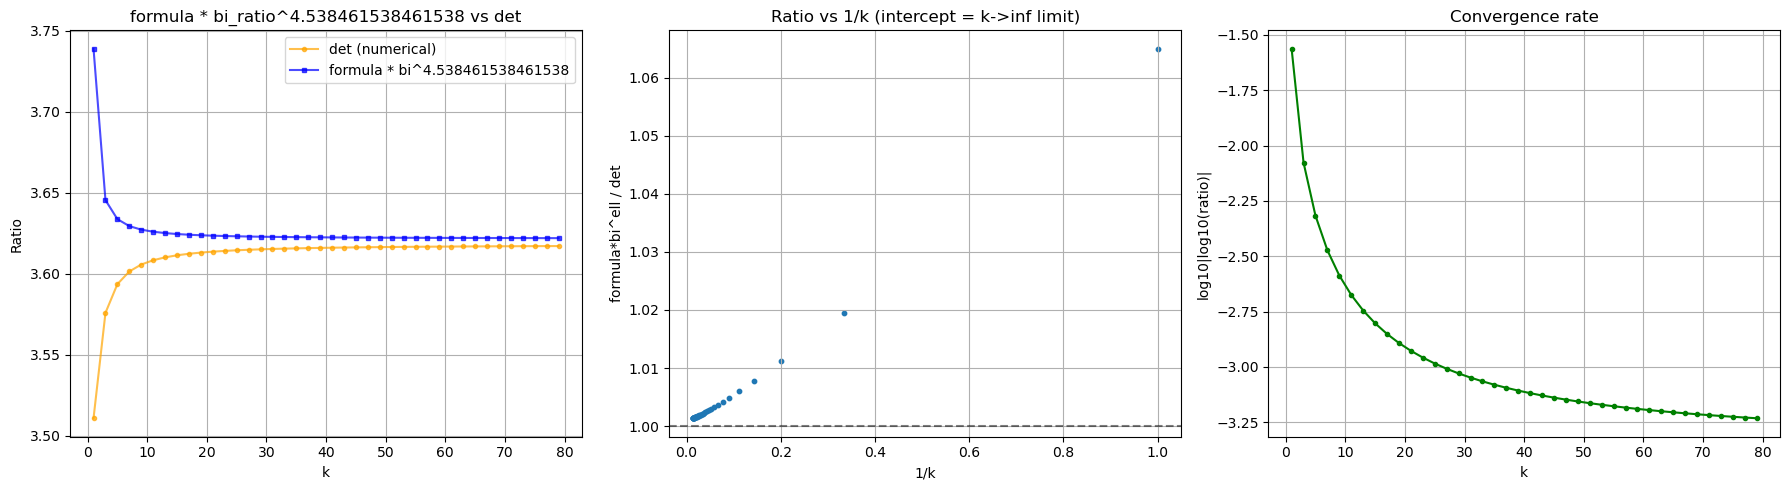

ell = 4.538461538461538
Last 5 ratios (formula*bi^ell / det): [1.00139668 1.00138451 1.00137306 1.0013623  1.00135218]
Extrapolated limit (mean of last 5): 1.00137374


In [78]:
# Plot formula * bi_ratio^ell vs det for user-chosen ell
ell = 59/13 # <-- change this to try different exponents

kvals = np.array(results2['kvals'], dtype=float)
formulas = np.array(results2['formula'])
dets = np.array(results2['det'])
bi_ratios = np.array(results2['bi_ratio'])

adjusted = formulas * bi_ratios**ell

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: direct comparison
axes[0].plot(kvals, dets, 'o-', color='orange', label='det (numerical)', alpha=0.7, markersize=3)
axes[0].plot(kvals, adjusted, 's-', color='blue', label=f'formula * bi^{ell}', alpha=0.7, markersize=3)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Ratio')
axes[0].set_title(f'formula * bi_ratio^{ell} vs det')
axes[0].legend()
axes[0].grid(True)

# Middle: ratio vs 1/k
ratio = adjusted / dets
axes[1].scatter(1/kvals, ratio, s=10)
axes[1].axhline(y=1.0, color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('1/k')
axes[1].set_ylabel('formula*bi^ell / det')
axes[1].set_title('Ratio vs 1/k (intercept = k->inf limit)')
axes[1].grid(True)

# Right: log-log convergence
axes[2].plot(kvals, np.log10(np.abs(np.log10(ratio))), 'o-', color='green', markersize=3)
axes[2].set_xlabel('k')
axes[2].set_ylabel('log10|log10(ratio)|')
axes[2].set_title('Convergence rate')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"ell = {ell}")
print(f"Last 5 ratios (formula*bi^ell / det): {ratio[-5:]}")
print(f"Extrapolated limit (mean of last 5): {np.mean(ratio[-5:]):.8f}")

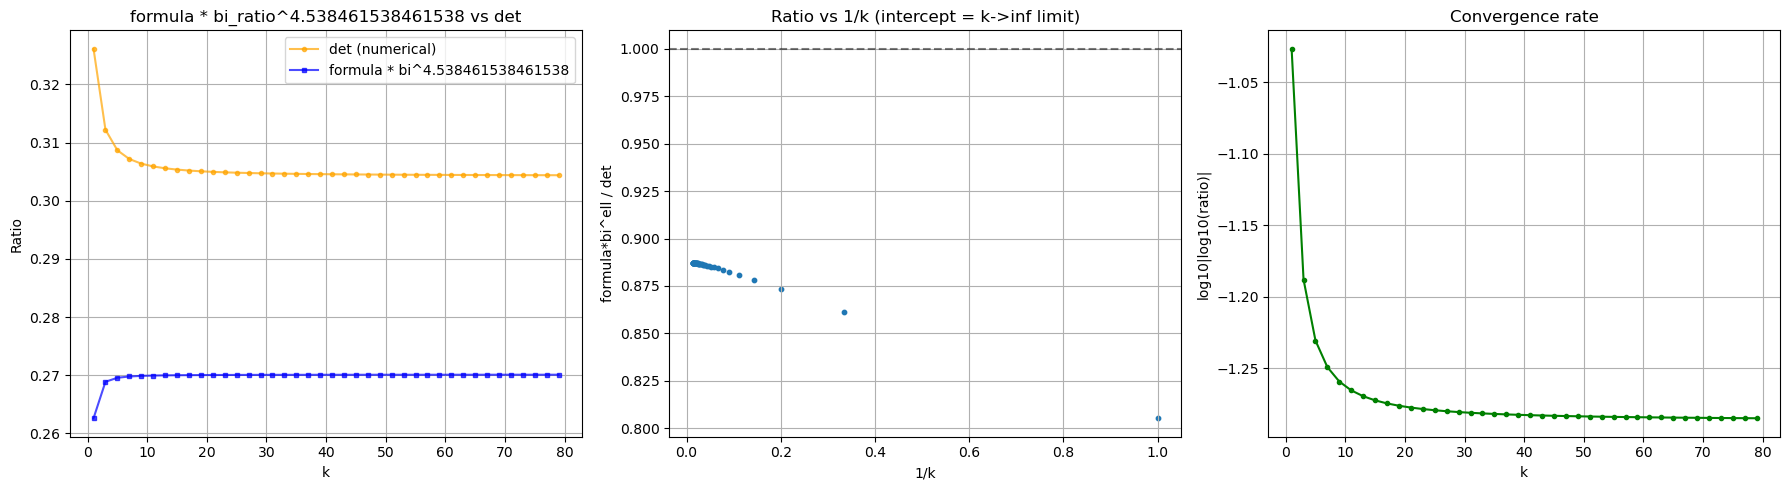

ell = 4.538461538461538
Last 5 ratios (formula*bi^ell / det): [0.88730414 0.88731981 0.88733453 0.88734834 0.88736133]
Extrapolated limit (mean of last 5): 0.88733363


In [80]:
# Plot formula * bi_ratio^ell vs det for user-chosen ell
ell = 59/13 # <-- change this to try different exponents

kvals = np.array(results3['kvals'], dtype=float)
formulas = np.array(results3['formula'])
dets = np.array(results3['det'])
bi_ratios = np.array(results3['bi_ratio'])

adjusted = formulas * bi_ratios**ell

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: direct comparison
axes[0].plot(kvals, dets, 'o-', color='orange', label='det (numerical)', alpha=0.7, markersize=3)
axes[0].plot(kvals, adjusted, 's-', color='blue', label=f'formula * bi^{ell}', alpha=0.7, markersize=3)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Ratio')
axes[0].set_title(f'formula * bi_ratio^{ell} vs det')
axes[0].legend()
axes[0].grid(True)

# Middle: ratio vs 1/k
ratio = adjusted / dets
axes[1].scatter(1/kvals, ratio, s=10)
axes[1].axhline(y=1.0, color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('1/k')
axes[1].set_ylabel('formula*bi^ell / det')
axes[1].set_title('Ratio vs 1/k (intercept = k->inf limit)')
axes[1].grid(True)

# Right: log-log convergence
axes[2].plot(kvals, np.log10(np.abs(np.log10(ratio))), 'o-', color='green', markersize=3)
axes[2].set_xlabel('k')
axes[2].set_ylabel('log10|log10(ratio)|')
axes[2].set_title('Convergence rate')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"ell = {ell}")
print(f"Last 5 ratios (formula*bi^ell / det): {ratio[-5:]}")
print(f"Extrapolated limit (mean of last 5): {np.mean(ratio[-5:]):.8f}")

Optimal ell = 3.888709
Extrapolated a (should be 1): 1.0000002481
|a - 1| = 2.48e-07


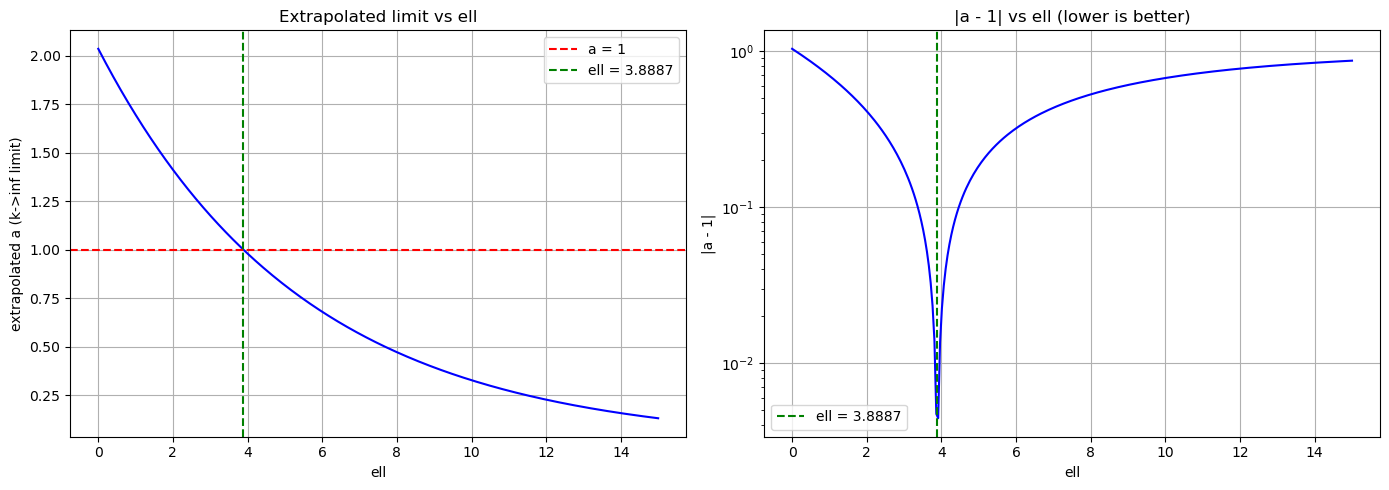


       ell      a (k->inf)       |a-1|
----------------------------------------
    4.0000      0.97987024  2.01e-02
    4.5000      0.89431607  1.06e-01
    4.3333      0.92197019  7.80e-02
    4.3333      0.92197019  7.80e-02
    5.0000      0.81623177  1.84e-01
    5.5000      0.74496515  2.55e-01
    6.0000      0.67992095  3.20e-01
    6.5000      0.62055587  3.79e-01
    7.0000      0.56637405  4.34e-01


In [81]:
# Find optimal ell: formula * bi_ratio^ell -> det as k->inf
# Strategy: for each candidate ell, fit (formula*bi^ell)/det = a + b/k, then check if a=1

from scipy.optimize import minimize_scalar, curve_fit

kvals = np.array(results3['kvals'], dtype=float)
formulas = np.array(results3['formula'])
dets = np.array(results3['det'])
bi_ratios = np.array(results3['bi_ratio'])

min_k_fit = 21  # only use large-k data for fitting

def extrapolated_a(ell):
    """For a given ell, fit ratio = a + b/k and return a."""
    adjusted = formulas * bi_ratios**ell
    ratio = adjusted / dets
    mask = kvals >= min_k_fit
    k_fit = kvals[mask]
    r_fit = ratio[mask]
    def model(k, a, b):
        return a + b / k
    popt, _ = curve_fit(model, k_fit, r_fit)
    return popt[0]

def cost(ell):
    """(a - 1)^2 where a is the extrapolated k->inf limit."""
    return (extrapolated_a(ell) - 1.0)**2

result = minimize_scalar(cost, bounds=(0, 20), method='bounded')
ell_opt = result.x
a_opt = extrapolated_a(ell_opt)

print(f"Optimal ell = {ell_opt:.6f}")
print(f"Extrapolated a (should be 1): {a_opt:.10f}")
print(f"|a - 1| = {abs(a_opt - 1):.2e}")

# Also scan a range to show the landscape
ells = np.linspace(0, 15, 300)
a_vals = [extrapolated_a(e) for e in ells]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ells, a_vals, 'b-')
axes[0].axhline(y=1.0, color='r', ls='--', label='a = 1')
axes[0].axvline(x=ell_opt, color='g', ls='--', label=f'ell = {ell_opt:.4f}')
axes[0].set_xlabel('ell')
axes[0].set_ylabel('extrapolated a (k->inf limit)')
axes[0].set_title('Extrapolated limit vs ell')
axes[0].legend()
axes[0].grid(True)

# Zoom near optimum
axes[1].plot(ells, np.abs(np.array(a_vals) - 1), 'b-')
axes[1].axvline(x=ell_opt, color='g', ls='--', label=f'ell = {ell_opt:.4f}')
axes[1].set_xlabel('ell')
axes[1].set_ylabel('|a - 1|')
axes[1].set_title('|a - 1| vs ell (lower is better)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Check nearby "nice" fractions
nice_vals = [4, 9/2, 13/3, 52/12, 5, 11/2, 6, 13/2, 7]
print(f"\n{'ell':>10s}  {'a (k->inf)':>14s}  {'|a-1|':>10s}")
print("-" * 40)
for e in nice_vals:
    a = extrapolated_a(e)
    print(f"{e:10.4f}  {a:14.8f}  {abs(a-1):.2e}")

formula test num=(1k, 11k), den=(5k, 7k)
L_formula = 24*k, L_det = 24*(k+1), bi_exponent = 4.5
l3_den_formula = 0*k, l3_num_formula = 0*k

k=  1: L_f=  24, L_d=  48, formula=2.363316e+03, formula2=-8.820016e+03, det=1.332787e+03
k=  3: L_f=  72, L_d=  96, formula=2.363316e+03, formula2=-8.820016e+03, det=1.780001e+03
k=  5: L_f= 120, L_d= 144, formula=2.363316e+03, formula2=-8.820016e+03, det=1.958353e+03
k=  7: L_f= 168, L_d= 192, formula=2.363316e+03, formula2=-8.820016e+03, det=2.053446e+03
k=  9: L_f= 216, L_d= 240, formula=2.363316e+03, formula2=-8.820016e+03, det=2.112439e+03
k= 11: L_f= 264, L_d= 288, formula=2.363316e+03, formula2=-8.820016e+03, det=2.152586e+03
k= 13: L_f= 312, L_d= 336, formula=2.363316e+03, formula2=-8.820016e+03, det=2.181666e+03
k= 15: L_f= 360, L_d= 384, formula=2.363316e+03, formula2=-8.820016e+03, det=2.203698e+03
k= 17: L_f= 408, L_d= 432, formula=2.363316e+03, formula2=-8.820016e+03, det=2.220966e+03
k= 19: L_f= 456, L_d= 480, formula=2.363316e+03, fo

/var/folders/_j/l6k6r9rj3j35xqbl94tt6lfc0000gn/T/ipykernel_42438/2694833442.py:31: RuntimeWarning: invalid value encountered in log10
  axes[1, 0].plot(kvals, np.log10(np.abs(np.log10(ratio2))), 'o-', color='purple', label='det / formula 2')
/var/folders/_j/l6k6r9rj3j35xqbl94tt6lfc0000gn/T/ipykernel_42438/2694833442.py:40: RuntimeWarning: invalid value encountered in log10
  axes[1, 1].plot(kvals, np.log10(np.abs(np.log10(ratio2))), '^-', color='purple', label='det / formula 2')


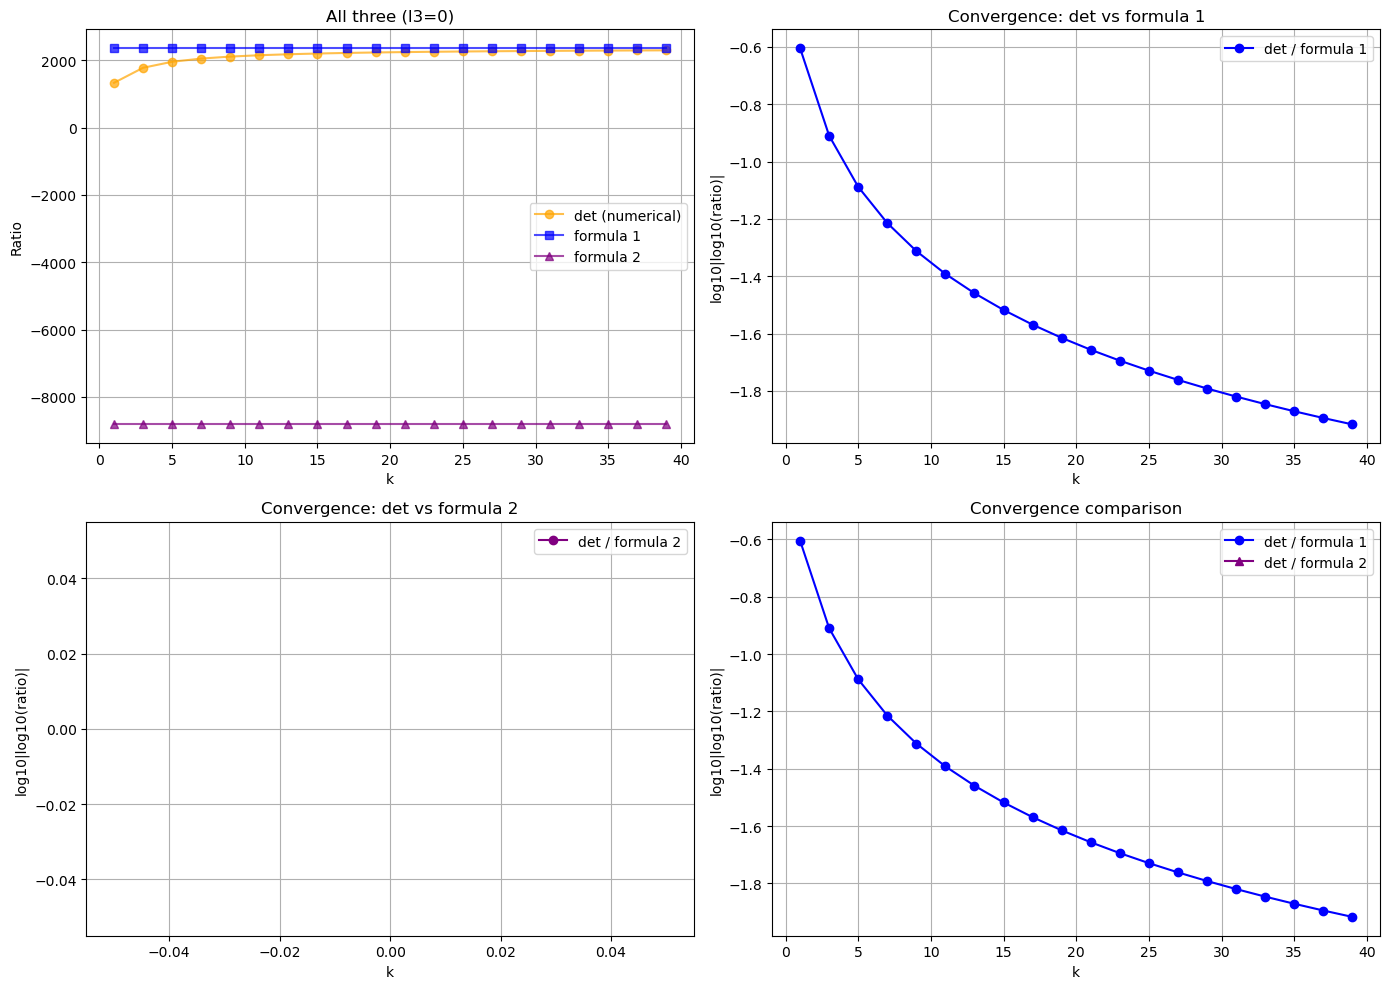

In [84]:
results = test_formula(1, 11, 5, 7, 24, range(1, 41, 2), plot=False)
plot_results(results, title_suffix=' (l3=0)')

In [64]:
results2 = test_formula(3, 9, 7,3, 26, range(1, 151, 2), plot=False)
plot_results(results2, title_suffix=' (l3=0)')

formula test num=(3k, 9k), den=(7k, 3k)
L_formula = 26*k, L_det = 26*(k+1), bi_exponent = 4.5
l3_den_formula = 3*k, l3_num_formula = 1*k

k=  1: L_f=  26, L_d=  52, formula=8.354294e+00, formula2=6.792087e+00, det=6.552403e+00
k=  3: L_f=  78, L_d= 104, formula=8.010335e+00, formula2=6.512446e+00, det=6.916317e+00
k=  5: L_f= 130, L_d= 156, formula=7.971075e+00, formula2=6.480528e+00, det=7.015753e+00
k=  7: L_f= 182, L_d= 208, formula=7.957531e+00, formula2=6.469516e+00, det=7.058836e+00
k=  9: L_f= 234, L_d= 260, formula=7.950973e+00, formula2=6.464184e+00, det=7.082055e+00
k= 11: L_f= 286, L_d= 312, formula=7.947199e+00, formula2=6.461116e+00, det=7.096276e+00
k= 13: L_f= 338, L_d= 364, formula=7.944787e+00, formula2=6.459155e+00, det=7.105748e+00
k= 15: L_f= 390, L_d= 416, formula=7.943130e+00, formula2=6.457808e+00, det=7.112445e+00
k= 17: L_f= 442, L_d= 468, formula=7.941932e+00, formula2=6.456834e+00, det=7.117394e+00
k= 19: L_f= 494, L_d= 520, formula=7.941031e+00, formula2=6.4

KeyboardInterrupt: 

In [85]:
from scipy.optimize import curve_fit

def fit_and_extrapolate(results, key='formula', min_k=11):
    """Fit ratio = a + b/k to formula/det data and extrapolate to k->inf."""
    kvals = np.array(results['kvals'], dtype=float)
    ratio = np.array(results[key]) / np.array(results['det'])
    
    mask = kvals >= min_k
    k_fit = kvals[mask]
    r_fit = ratio[mask]
    
    # Fit: ratio = a + b/k
    def model(k, a, b):
        return a + b / k
    
    # Fit: ratio = a + b/k + c/k^2
    def model2(k, a, b, c):
        return a + b / k + c / k**2
    
    popt, _ = curve_fit(model, k_fit, r_fit)
    popt2, _ = curve_fit(model2, k_fit, r_fit)
    
    print(f"=== Fit: ratio = a + b/k (using k >= {min_k}) ===")
    print(f"  a = {popt[0]:.8f}")
    print(f"  b = {popt[1]:.6f}")
    print(f"  => k->inf limit: {popt[0]:.8f}")
    
    print(f"\n=== Fit: ratio = a + b/k + c/k^2 ===")
    print(f"  a = {popt2[0]:.8f}")
    print(f"  b = {popt2[1]:.6f}")
    print(f"  c = {popt2[2]:.6f}")
    print(f"  => k->inf limit: {popt2[0]:.8f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Left: raw ratio with fit
    axes[0].scatter(kvals, ratio, s=10, label='data')
    k_smooth = np.linspace(kvals.min(), kvals.max()*2, 500)
    axes[0].plot(k_smooth, model(k_smooth, *popt), 'r-', label=f'a+b/k, a={popt[0]:.4f}')
    axes[0].axhline(y=1.0, color='k', ls='--', alpha=0.5, label='y=1')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel(f'{key} / det')
    axes[0].set_title(f'{key}/det vs k')
    axes[0].legend()
    axes[0].grid(True)
    
    # Middle: ratio vs 1/k (should be linear)
    axes[1].scatter(1/kvals, ratio, s=10, label='data')
    inv_k_smooth = np.linspace(0, 1/kvals.min(), 200)
    axes[1].plot(inv_k_smooth, popt[0] + popt[1]*inv_k_smooth, 'r-', label=f'a+b/k fit')
    axes[1].axhline(y=1.0, color='k', ls='--', alpha=0.5)
    axes[1].set_xlabel('1/k')
    axes[1].set_ylabel(f'{key} / det')
    axes[1].set_title('Linear in 1/k (intercept = k->inf limit)')
    axes[1].legend()
    axes[1].grid(True)
    
    # Right: residuals from 2-param fit
    resid = ratio - model(kvals, *popt)
    axes[2].scatter(kvals, resid, s=10, label='residual from a+b/k')
    axes[2].axhline(y=0, color='k', ls='--', alpha=0.5)
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Residual')
    axes[2].set_title('Residuals (should be ~b₂/k²)')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return {'a': popt[0], 'b': popt[1], 'a3': popt2[0], 'b3': popt2[1], 'c3': popt2[2]}

# Run for formula 1
print("=== FORMULA 1 ===")
fit1 = fit_and_extrapolate(results, key='formula',min_k=101)
print()
# Run for formula 2
print("=== FORMULA 2 ===")
#fit2 = fit_and_extrapolate(results, key='formula2')

=== FORMULA 1 ===


ValueError: `ydata` must not be empty!

In [ ]:
fit1 = fit_and_extrapolate(results, key='formula',min_k=101)

In [58]:
print(results["kvals"])
print(np.array(results["formula"])/np.array(results["det"]))

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 137, 139, 141, 143, 145, 147, 149]
[1.09051013 1.04388912 1.02895373 1.02160066 1.01722552 1.01432406
 1.01225908 1.01071443 1.00951547 1.00855782 1.0077753  1.00712389
 1.0065732  1.00610153 1.00569302 1.00533578 1.00502072 1.0047408
 1.00449044 1.0042652  1.00406147 1.00387632 1.00370731 1.00355242
 1.00340997 1.00327849 1.00315677 1.00304377 1.00293858 1.00284042
 1.0027486  1.00266255 1.00258169 1.00250563 1.00243389 1.00236616
 1.00230212 1.00224143 1.00218385 1.00212916 1.00207717 1.00202764
 1.00198042 1.00193534 1.00189226 1.00185107 1.00181164 1.00177382
 1.00173761 1.00170277 1.00166939 1.00163723 1.00160628 1.00157648
 1.00154779 1.00152019 1.00149346 1.00146771 1.00144274 1.00141868
 1.0013953

In [ ]:
# Example: test with num=(5,7), den=(3,1), L=26
# The default plot tries powers [0, 9/2, 52/12, 4, 5]
results2 = test_formula2(5, 7, 3, 1, 26, range(1, 41, 2))

# You can also manually plot with a custom power:
formulas_arr = np.array(results2['formula'])
dets_arr = np.array(results2['det'])
bi_arr = np.array(results2['bi_ratio'])
kvals = results2['kvals']

custom_power = 9/2
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(kvals, dets_arr, 'ko-', label='det', lw=2)
ax.plot(kvals, formulas_arr * bi_arr**custom_power, 'ro-', label=f'formula * bi^{custom_power}', alpha=0.7)
ax.legend()
ax.grid(True)
ax.set_title(f'Custom power = {custom_power}')
plt.tight_layout()
plt.show()

formula test num=(5k, 7k), den=(3k, 9k)
L_formula = 24*k, L_det = 24*(k+1), bi_exponent = 4.5
l3_den_formula = 0*k, l3_num_formula = 0*k

1.1959086344254605e+19
k=  1: L_f=  24, L_d=  48, formula=1.325191e-01, formula2=4.309368e-01, det=2.063351e-01
1.195908634425461e+19
k=  3: L_f=  72, L_d=  96, formula=1.325191e-01, formula2=4.309368e-01, det=1.975140e-01


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:236: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/2) *


1.1959086344254605e+19
k=  5: L_f= 120, L_d= 144, formula=1.325191e-01, formula2=4.309368e-01, det=1.946881e-01
1.195908634425461e+19
k=  7: L_f= 168, L_d= 192, formula=1.325191e-01, formula2=4.309368e-01, det=1.932968e-01
1.1959086344254605e+19
k=  9: L_f= 216, L_d= 240, formula=1.325191e-01, formula2=4.309368e-01, det=1.924690e-01
1.1959086344254605e+19
k= 11: L_f= 264, L_d= 288, formula=1.325191e-01, formula2=4.309368e-01, det=1.919200e-01
1.195908634425461e+19
k= 13: L_f= 312, L_d= 336, formula=1.325191e-01, formula2=4.309368e-01, det=1.915293e-01
1.1959086344254605e+19
k= 15: L_f= 360, L_d= 384, formula=1.325191e-01, formula2=4.309368e-01, det=1.912370e-01
1.1959086344254605e+19
k= 17: L_f= 408, L_d= 432, formula=1.325191e-01, formula2=4.309368e-01, det=1.910102e-01
1.1959086344254605e+19
k= 19: L_f= 456, L_d= 480, formula=1.325191e-01, formula2=4.309368e-01, det=1.908290e-01

Done.


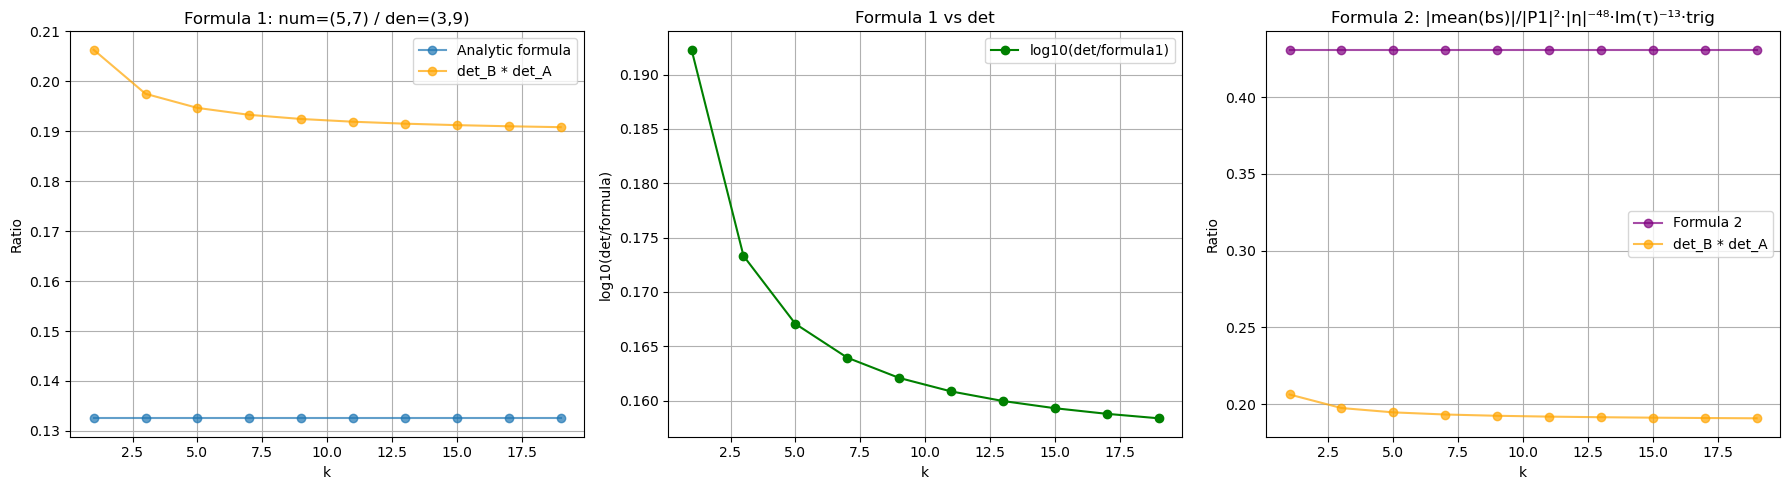

In [19]:
#double check things are being computed as before
results_19 = test_formula(5, 7, 3, 9,24, range(1, 21,2),bi_exponent=9/2)

In [77]:
38*2

76

In [ ]:
np.where(results_19["formula"]==np.max(results_19["formula"]))

(array([38]),)

In [95]:
sArray = []
pArray = []
for col, (z_vals, label) in enumerate([(z_real, 'z real'), (z_diag, 'z = r·e^{iπ/4}')]):
    f_num = []
    f_analytic = []
    for z in z_vals:
        s, p = f_improved(z)
        sArray.append(s)
        pArray.append(p)

In [97]:
pArray

[np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.complex128(1+0j),
 np.comple

L=3600, l1=750, l2=1050, l3=0


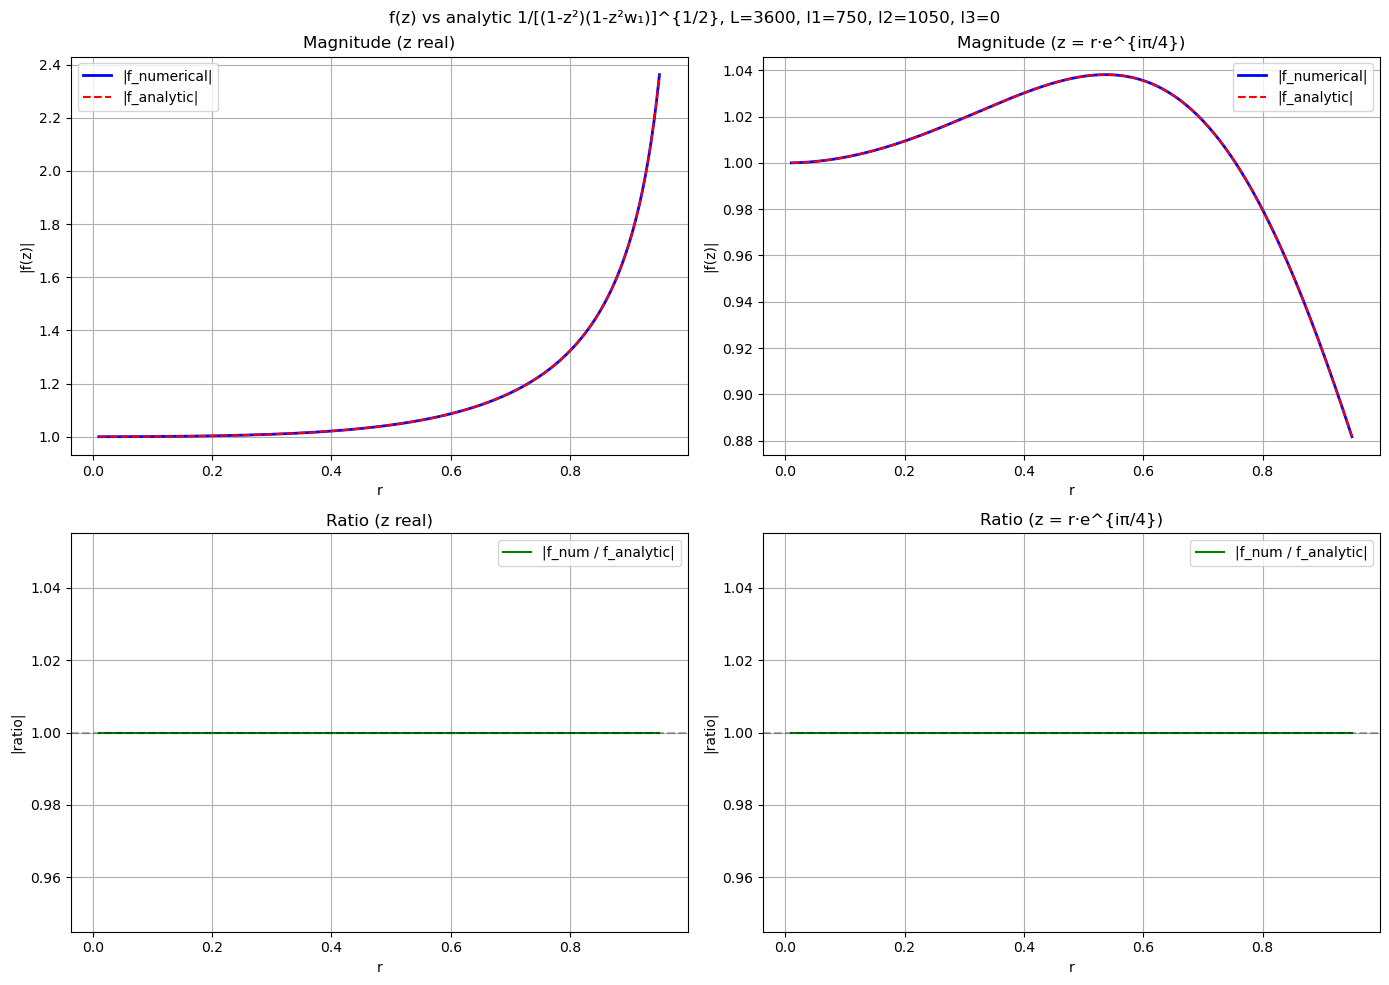


First 10 polynomial coefficients:
  c[0] = 1.00000000e+00+0.00000000e+00j
  c[1] = 0.00000000e+00+0.00000000e+00j
  c[2] = 0.00000000e+00+0.00000000e+00j
  c[3] = 0.00000000e+00+0.00000000e+00j
  c[4] = 0.00000000e+00+0.00000000e+00j
  c[5] = 0.00000000e+00+0.00000000e+00j
  c[6] = 0.00000000e+00+0.00000000e+00j
  c[7] = 0.00000000e+00+0.00000000e+00j
  c[8] = 0.00000000e+00+0.00000000e+00j
  c[9] = 0.00000000e+00+0.00000000e+00j
  ... (1801 total)


In [98]:
importlib.reload(et)

# Compare numerical f(z) from make_cyl_eqn_improved vs analytic expectation for l3=0
# Analytic: f(z) = 1/[(1-z^2)(1-z^2 e^{-2πi l1/L})]^{1/2} (just the singular part, poly=1)
# But the numerical f = singular * poly, so we compare singular*poly vs the analytic singular

L_test = 120*30  # = 24*5
l1_test = 25*30
l2_test = L_test // 2 - l1_test  # l3 = 0
print(f"L={L_test}, l1={l1_test}, l2={l2_test}, l3={L_test//2 - l1_test - l2_test}")

f_improved = et.make_cyl_eqn_improved(L_test, l1_test, l2_test)

# Sample z values along a radial line (real axis, inside unit disc)
z_real = np.linspace(0.01, 0.95, 200)

# Also sample along a line at angle pi/4
z_diag = z_real * np.exp(1j * np.pi / 4)

w1 = np.exp(-4j * np.pi * l1_test / L_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'f(z) vs analytic 1/[(1-z²)(1-z²w₁)]^{{1/2}}, L={L_test}, l1={l1_test}, l2={l2_test}, l3=0')

for col, (z_vals, label) in enumerate([(z_real, 'z real'), (z_diag, 'z = r·e^{iπ/4}')]):
    f_num = []
    f_analytic = []
    for z in z_vals:
        s, p = f_improved(z)
        f_num.append(s * p)
        f_analytic.append(((1 - z**2) * (1 - z**2 * w1))**(-1/2))
    
    f_num = np.array(f_num)
    f_analytic = np.array(f_analytic)
    
    # Top row: magnitude comparison
    axes[0, col].plot(z_real, np.abs(f_num), 'b-', label='|f_numerical|', lw=2)
    axes[0, col].plot(z_real, np.abs(f_analytic), 'r--', label='|f_analytic|', lw=1.5)
    axes[0, col].set_xlabel('r')
    axes[0, col].set_ylabel('|f(z)|')
    axes[0, col].set_title(f'Magnitude ({label})')
    axes[0, col].legend()
    axes[0, col].grid(True)
    
    # Bottom row: ratio (should be 1 if poly = 1)
    ratio = f_num / f_analytic
    axes[1, col].plot(z_real, np.abs(ratio), 'g-', label='|f_num / f_analytic|', lw=1.5)
    axes[1, col].axhline(1.0, color='black', ls='--', alpha=0.3)
    axes[1, col].set_xlabel('r')
    axes[1, col].set_ylabel('|ratio|')
    axes[1, col].set_title(f'Ratio ({label})')
    axes[1, col].legend()
    axes[1, col].grid(True)

plt.tight_layout()
plt.show()

# Also print the polynomial coefficients to see if poly ≈ 1
print(f"\nFirst 10 polynomial coefficients:")
for i, c in enumerate(f_improved.coeffs[:10]):
    print(f"  c[{i}] = {c:.8e}")
print(f"  ... ({len(f_improved.coeffs)} total)")

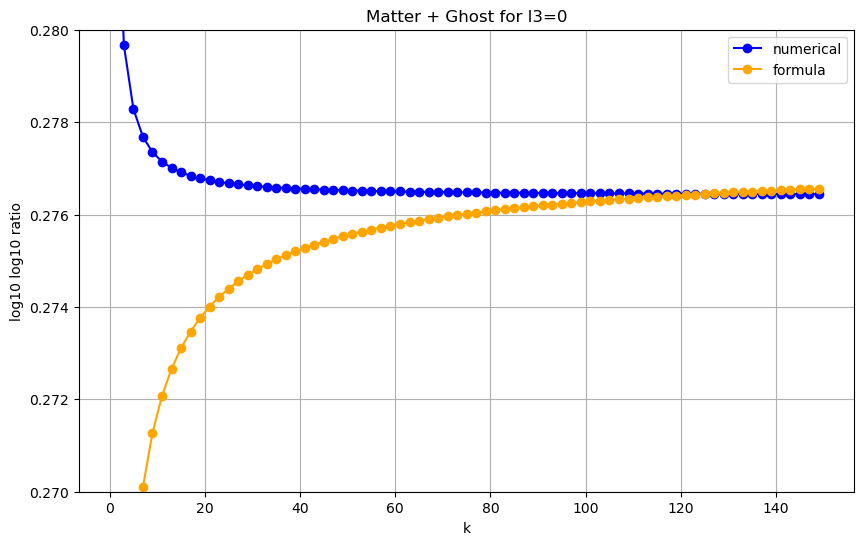

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
diff = np.array(results_19["det"])/np.array(results_19["formula"])
kvals = results_19["kvals"]
ax.plot(kvals, np.array(results_19["det"]), 'o-', color='blue', label='numerical')
ax.plot(kvals, np.array(results_19["formula"]), 'o-', color='orange', label='formula')
ax.set_xlabel('k')
ax.set_ylabel('log10 log10 ratio')
ax.set_ylim([0.27,0.28])
ax.set_title('Matter + Ghost for l3=0')
#ax.set_ylim([0.0,0.01])

plt.legend()
plt.grid(True)

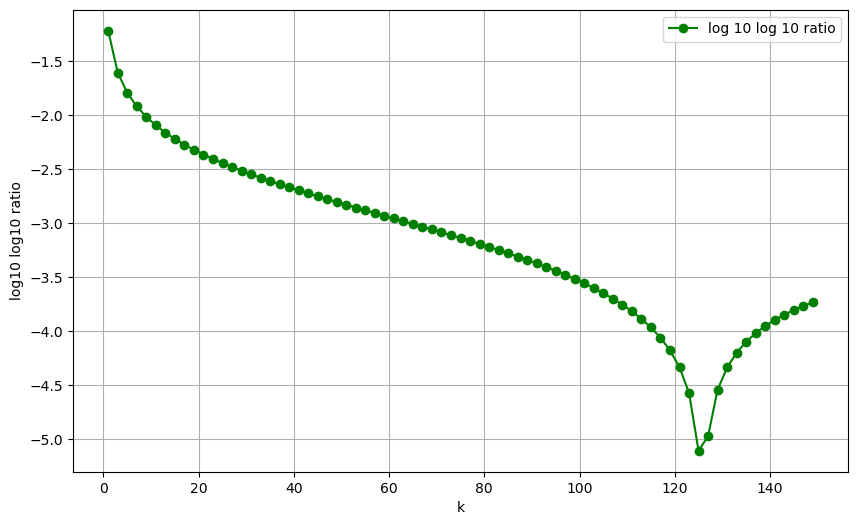

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
diff = np.array(results_19["det"])/np.array(results_19["formula"])
kvals = results_19["kvals"]
ax.plot(kvals, np.log10(np.abs(np.log10(diff))), 'o-', color='green', label='log 10 log 10 ratio')
ax.set_xlabel('k')
ax.set_ylabel('log10 log10 ratio')
#axes[1].set_title('Formula - Det')
#ax.set_ylim([0.0,0.01])

plt.legend()
plt.grid(True)

formula test num=(3k, 9k), den=(5k, 7k)
L_formula = 24*k, L_det = 24*(k+1), bi_exponent = 4.5
l3_den_formula = 0*k, l3_num_formula = 0*k

5.153574506398825e+18
k=  1: L_f=  24, L_d=  48, formula=7.967664e+00, det=4.846484e+00
2.438250109428831e+18
k=  3: L_f=  72, L_d=  96, formula=8.902590e+00, det=5.062933e+00
1.7322122068344082e+18
k=  5: L_f= 120, L_d= 144, formula=9.175014e+00, det=5.136422e+00
1.3836409274919493e+18
k=  7: L_f= 168, L_d= 192, formula=9.311064e+00, det=5.173392e+00


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:230: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *
/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:232: RuntimeWarning: invalid value encountered in scalar power
  (1 - z**2 * w2)**(-1/3))


1.170026017573821e+18
k=  9: L_f= 216, L_d= 240, formula=9.394432e+00, det=5.195643e+00
1.0234413794838237e+18
k= 11: L_f= 264, L_d= 288, formula=9.451503e+00, det=5.210505e+00
9.155404490620582e+17
k= 13: L_f= 312, L_d= 336, formula=9.493399e+00, det=5.221134e+00
8.322127423505597e+17
k= 15: L_f= 360, L_d= 384, formula=9.525673e+00, det=5.229113e+00
7.655765464131992e+17
k= 17: L_f= 408, L_d= 432, formula=9.551428e+00, det=5.235324e+00
7.108542388010036e+17
k= 19: L_f= 456, L_d= 480, formula=9.572541e+00, det=5.240295e+00
6.649668218301992e+17
k= 21: L_f= 504, L_d= 528, formula=9.590220e+00, det=5.244364e+00
6.25833037536109e+17
k= 23: L_f= 552, L_d= 576, formula=9.605280e+00, det=5.247756e+00
5.91991200391857e+17
k= 25: L_f= 600, L_d= 624, formula=9.618292e+00, det=5.250627e+00
5.623820371613222e+17
k= 27: L_f= 648, L_d= 672, formula=9.629669e+00, det=5.253088e+00
5.3621750984522464e+17
k= 29: L_f= 696, L_d= 720, formula=9.639718e+00, det=5.255222e+00
5.128981795611936e+17
k= 31: L_f

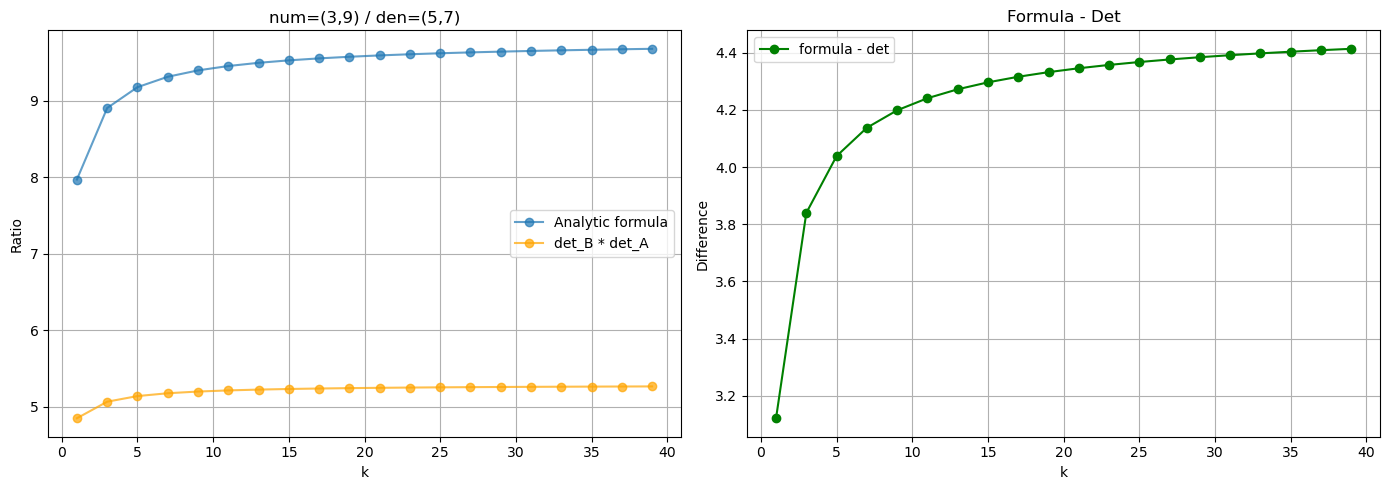

In [ ]:
# Reproduce cell 19 using the function: num=(3,9), den=(5,7)
results_19 = test_formula(3, 9, 5, 7, 24, range(1, 41, 2))

# Reproduce cell 21 using the function: num=(3,1), den=(9,13)
# Note: cell 21 had a bug where det used (5,7) instead of (9,13)
# This version correctly uses (9,13) for both formula and det
#results_21 = test_ben_formula_l3zero(3, 1, 9, 13, range(1, 101, 2))

In [ ]:
results_21 = test_formula_l3zero(1,10, 5,7,24,range(1, 101, 2))

Ben's formula test: num=(1k, 10k), den=(5k, 7k)
L_formula = 24*k, L_det = 26*(k+1), bi_exponent = 4.5
l3_den_formula = 0*k, l3_num_formula = 1*k

k=  1: L_f=  24, L_d=  52, formula=1.895509e-39, det=1.375283e+01
k=  3: L_f=  72, L_d= 104, formula=5.270401e-39, det=1.436784e+01
k=  5: L_f= 120, L_d= 156, formula=9.665783e-39, det=1.453784e+01
k=  7: L_f= 168, L_d= 208, formula=1.470046e-38, det=1.461293e+01


/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:230: RuntimeWarning: invalid value encountered in scalar power
  singular = ((1 - z**2)**(-1/3) *
/Users/sam/Documents/research/string_notes/strebel_differential/python_code/ell_to_tau.py:232: RuntimeWarning: invalid value encountered in scalar power
  (1 - z**2 * w2)**(-1/3))


k=  9: L_f= 216, L_d= 260, formula=2.026136e-38, det=1.465404e+01
k= 11: L_f= 264, L_d= 312, formula=2.628007e-38, det=1.467952e+01
k= 13: L_f= 312, L_d= 364, formula=3.270863e-38, det=1.469666e+01
k= 15: L_f= 360, L_d= 416, formula=3.951089e-38, det=1.470887e+01
k= 17: L_f= 408, L_d= 468, formula=4.665836e-38, det=1.471795e+01
k= 19: L_f= 456, L_d= 520, formula=5.412779e-38, det=1.472493e+01
k= 21: L_f= 504, L_d= 572, formula=6.189983e-38, det=1.473045e+01
k= 23: L_f= 552, L_d= 624, formula=6.995797e-38, det=1.473490e+01
k= 25: L_f= 600, L_d= 676, formula=7.828799e-38, det=1.473855e+01
k= 27: L_f= 648, L_d= 728, formula=8.687743e-38, det=1.474160e+01
k= 29: L_f= 696, L_d= 780, formula=9.571528e-38, det=1.474418e+01
k= 31: L_f= 744, L_d= 832, formula=1.047917e-37, det=1.474638e+01
k= 33: L_f= 792, L_d= 884, formula=1.140980e-37, det=1.474829e+01


KeyboardInterrupt: 

In [110]:
from scipy.special import ellipk

def periods_prime(l1, l2):
    """Analytic periods for l3=0 case.
    
    kappa = e^{i theta1/2} * K(cos^2(theta1/2))
    tau = i * K(sin^2(theta1/2)) / K(cos^2(theta1/2))
    
    where theta1 = 2*pi*l1 / L, L = 2*(l1+l2).
    """
    L = 2 * (l1 + l2)
    theta1 = 2 * np.pi * l1 / L
    
    m = np.cos(theta1 / 2)**2  # parameter for K
    m_comp = np.sin(theta1 / 2)**2  # = 1 - m
    
    K_m = ellipk(m)
    K_comp = ellipk(m_comp)
    
    kappa = np.exp(1j * theta1 / 2) * K_m
    tau_prime = 1j * K_comp / K_m
    
    return kappa, tau_prime

In [ ]:
importlib.reload(et)

# Compare analytic tau_prime vs numerical tau from periods_improved for l3=0
# Scan over several (l1, l2) with l3=0, at various k scalings

test_cases = [
    (3, 9),   # l1=3k, l2=9k, L=24k
    (5, 7),   # l1=5k, l2=7k, L=24k
    (1, 11),  # l1=1k, l2=11k, L=24k
    (4, 8),   # l1=4k, l2=8k, L=24k
    (2, 5),   # l1=2k, l2=5k, L=14k
]

print(f"{'l1':>6s} {'l2':>6s} {'L':>6s} {'k':>4s}  {'tau_num':>30s}  {'tau_prime':>30s}  {'|diff|':>12s}")
print("-" * 105)

for l1_s, l2_s in test_cases:
    L_s = 2 * (l1_s + l2_s)
    for k in [1, 5, 11, 21, 51]:
        l1 = l1_s * k
        l2 = l2_s * k
        L = L_s * k
        
        # Numerical
        P1, P2, P3 = et.periods_improved(L, l1, l2)
        tau_num = P2 / P1
        
        # Analytic
        kappa, tau_prime = periods_prime(l1, l2)
        
        diff = abs(tau_num - tau_prime)
        print(f"{l1:6d} {l2:6d} {L:6d} {k:4d}  {tau_num.real:+.10f}{tau_num.imag:+.10f}i  "
              f"{tau_prime.real:+.10f}{tau_prime.imag:+.10f}i  {diff:.6e}")
    print()

    l1     l2      L    k                         tau_num                       tau_prime        |diff|
---------------------------------------------------------------------------------------------------------
     3      9     24    1  +0.0000000000+0.6806341731i  +0.0000000000+0.6806341731i  9.313765e-13
    15     45    120    5  +0.0000000000+0.6806341731i  +0.0000000000+0.6806341731i  9.313765e-13
    33     99    264   11  +0.0000000000+0.6806341731i  +0.0000000000+0.6806341731i  9.313765e-13
    63    189    504   21  +0.0000000000+0.6806341731i  +0.0000000000+0.6806341731i  9.313765e-13
   153    459   1224   51  +0.0000000000+0.6806341731i  +0.0000000000+0.6806341731i  9.313765e-13

     5      7     24    1  +0.0000000000+0.8865066851i  +0.0000000000+0.8865066851i  5.833061e-13
    25     35    120    5  +0.0000000000+0.8865066851i  +0.0000000000+0.8865066851i  5.833061e-13
    55     77    264   11  +0.0000000000+0.8865066851i  +0.0000000000+0.8865066851i  5.833061e-13
   10